# 03 — Modellierung

**Scope:** Baseline-Regel, Random Forest, XGBoost, Logistische Regression, Champion-Challenger-Vergleich, Class Imbalance Analyse.

Verwendet die aufbereiteten Daten aus `data/processed/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src.modeling import (
    evaluate_model, baseline_rule,
    train_random_forest, tune_random_forest,
    train_xgboost, tune_xgboost,
    train_logistic_regression, plot_coefficients,
    plot_confusion_matrix, plot_roc_curves, plot_feature_importance,
    compare_models, threshold_analysis, plot_precision_recall_curve,
    apply_smote,
)

sns.set_theme(style="whitegrid", font_scale=1.2)
CHURN_COLORS_01 = {1: "#e74c3c", 0: "#3498db"}
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# Daten laden (aus Notebook 02 gespeichert)
X_train = pd.read_csv("data/processed/X_train.csv")
X_test = pd.read_csv("data/processed/X_test.csv")
y_train = pd.read_csv("data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("data/processed/y_test.csv").squeeze()

print(f"Training: {X_train.shape}, Test: {X_test.shape}")
print(f"Churn-Rate Train: {y_train.mean():.3f}, Test: {y_test.mean():.3f}")

feature_names = list(X_train.columns)

Training: (4930, 32), Test: (2113, 32)
Churn-Rate Train: 0.265, Test: 0.265


---
## 5. Baseline: Einfache Regel

Regel: **Monatsvertrag UND tenure < 12 Monate = Churn**


  Baseline-Regel
              precision    recall  f1-score   support

           0     0.8265    0.8254    0.8259      1552
           1     0.5187    0.5205    0.5196       561

    accuracy                         0.7444      2113
   macro avg     0.6726    0.6729    0.6727      2113
weighted avg     0.7447    0.7444    0.7446      2113

AUC-ROC: 0.6729


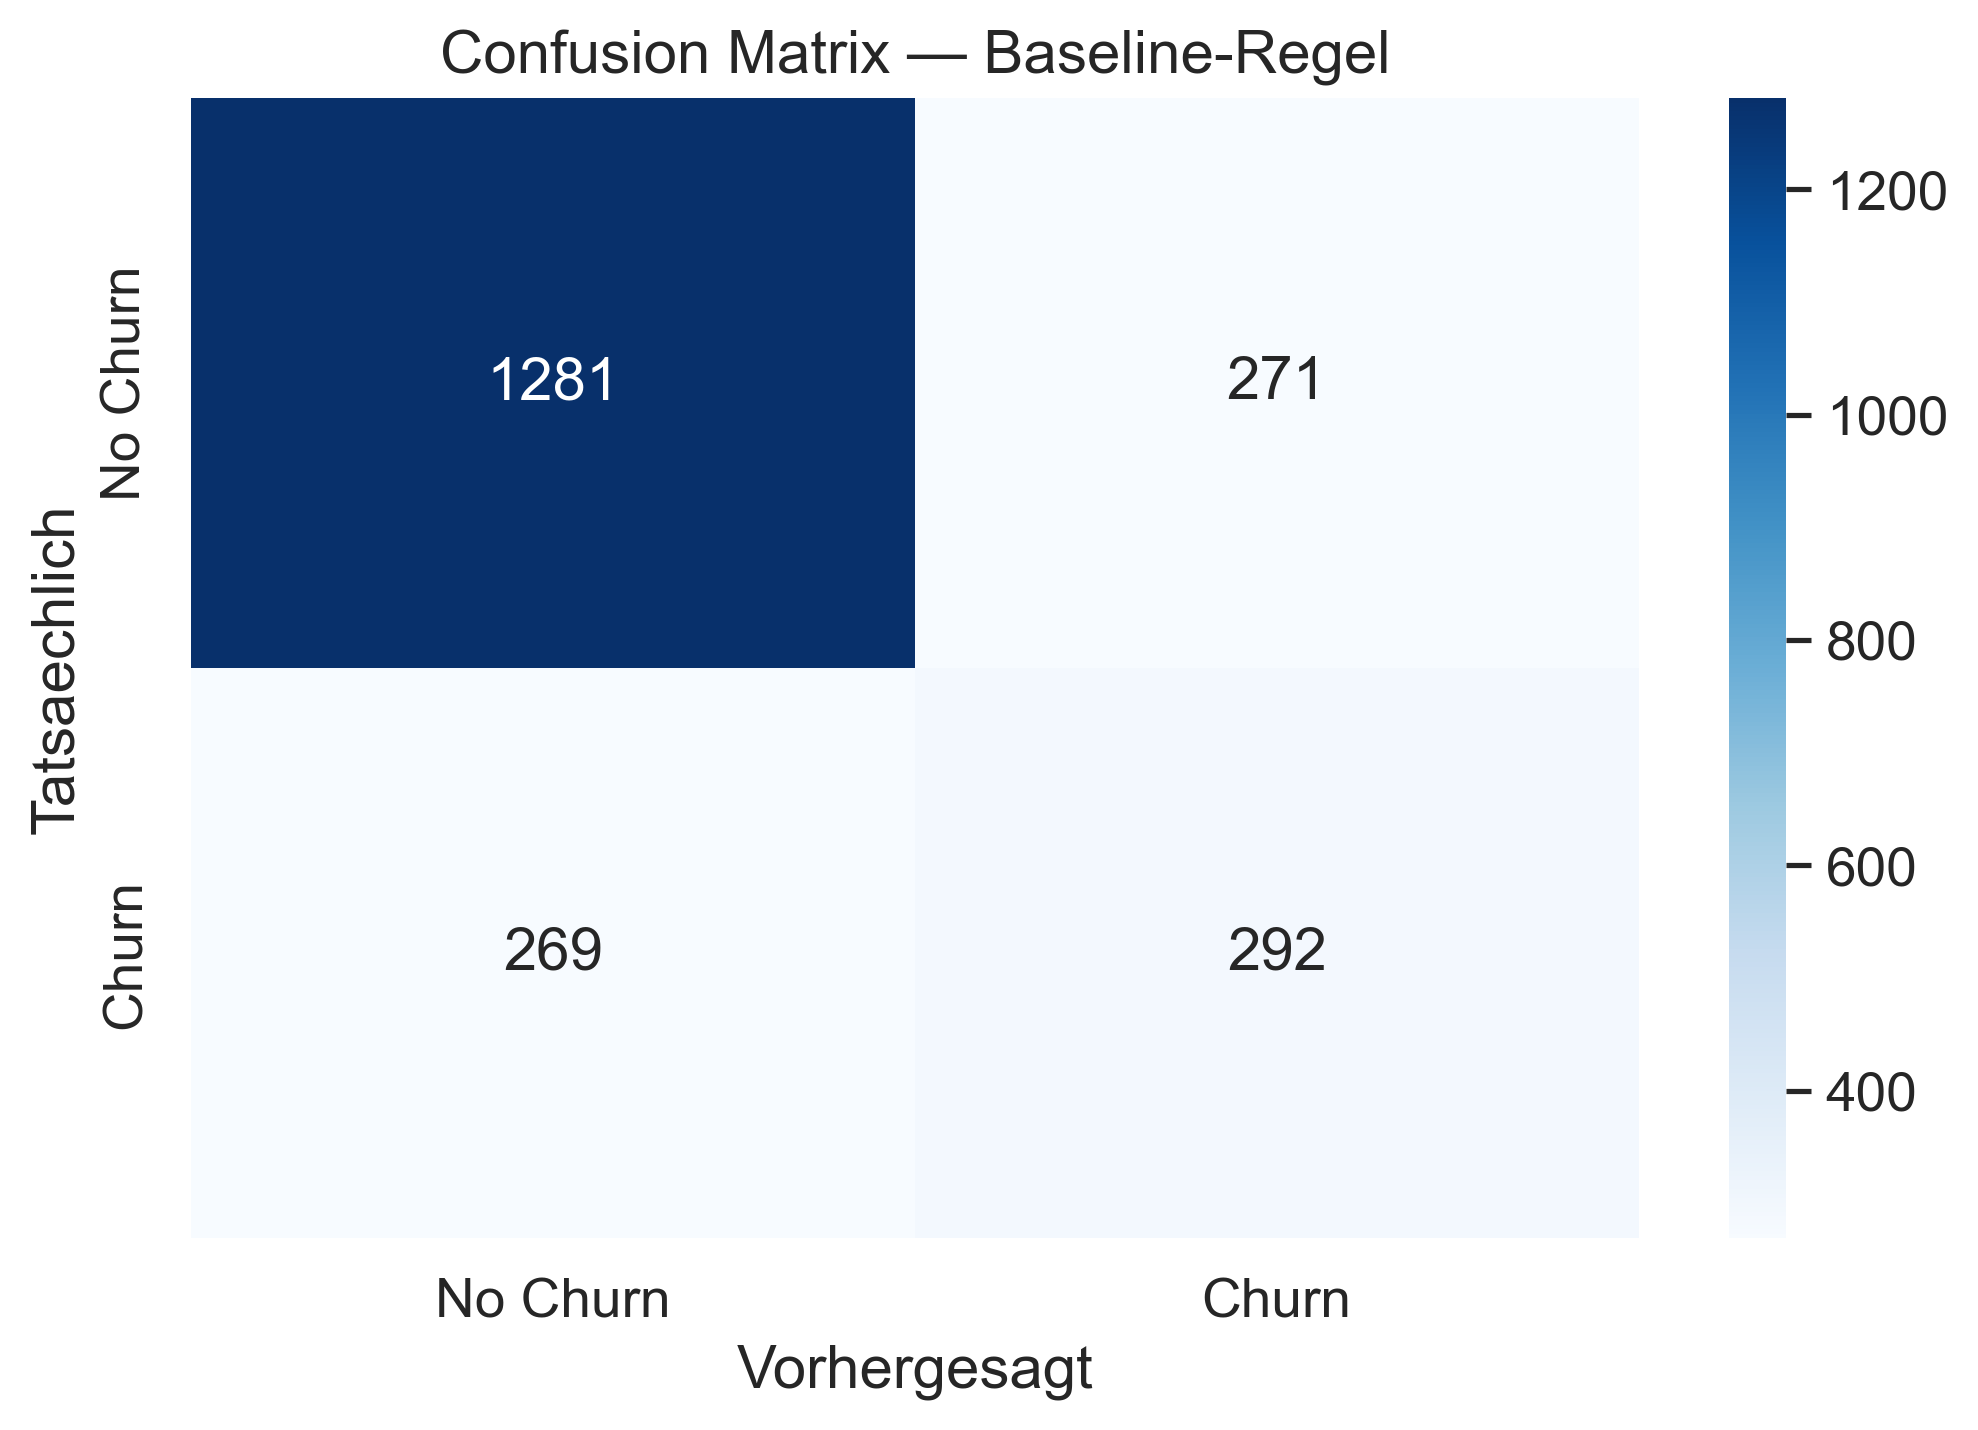

In [3]:
y_pred_base, y_prob_base = baseline_rule(X_test)

res_baseline = evaluate_model(
    None, X_test, y_test, model_name="Baseline-Regel",
    y_pred=y_pred_base, y_prob=y_prob_base,
)
res_baseline["y_test"] = y_test

plot_confusion_matrix(y_test, y_pred_base, model_name="Baseline-Regel", filename="12_confusion_matrix_baseline.png")
plt.show()

---
## 6. Random Forest

### 6.1 Ohne Class Balancing

In [4]:
rf_plain = train_random_forest(X_train, y_train)
res_rf_plain = evaluate_model(rf_plain, X_test, y_test, "RF (unbalanced)")


  RF (unbalanced)
              precision    recall  f1-score   support

           0     0.8251    0.8969    0.8595      1552
           1     0.6244    0.4742    0.5390       561

    accuracy                         0.7847      2113
   macro avg     0.7248    0.6855    0.6993      2113
weighted avg     0.7718    0.7847    0.7744      2113

AUC-ROC: 0.8232


### 6.2 Mit Class Balancing

In [5]:
rf_balanced = train_random_forest(X_train, y_train, class_weight="balanced")
res_rf_balanced = evaluate_model(rf_balanced, X_test, y_test, "RF (balanced)")

print("\n--- Vergleich Vorher/Nachher ---")
print(f"Recall: {res_rf_plain['recall']:.3f} -> {res_rf_balanced['recall']:.3f}")
print(f"F1:     {res_rf_plain['f1']:.3f} -> {res_rf_balanced['f1']:.3f}")


  RF (balanced)
              precision    recall  f1-score   support

           0     0.8223    0.8943    0.8568      1552
           1     0.6141    0.4652    0.5294       561

    accuracy                         0.7804      2113
   macro avg     0.7182    0.6798    0.6931      2113
weighted avg     0.7670    0.7804    0.7699      2113

AUC-ROC: 0.8234

--- Vergleich Vorher/Nachher ---
Recall: 0.474 -> 0.465
F1:     0.539 -> 0.529


### 6.3 Hyperparameter-Tuning

In [6]:
rf_tuned, rf_search = tune_random_forest(X_train, y_train, n_iter=50, cv=5)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


Beste Parameter: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 10, 'class_weight': 'balanced'}
Bester F1 (CV): 0.6364


In [7]:
res_rf_tuned = evaluate_model(rf_tuned, X_test, y_test, "RF (tuned)")
res_rf_tuned["y_test"] = y_test


  RF (tuned)
              precision    recall  f1-score   support

           0     0.8935    0.7784    0.8320      1552
           1     0.5480    0.7433    0.6309       561

    accuracy                         0.7690      2113
   macro avg     0.7207    0.7608    0.7314      2113
weighted avg     0.8018    0.7690    0.7786      2113

AUC-ROC: 0.8444


### 6.4 Ergebnis-Outputs

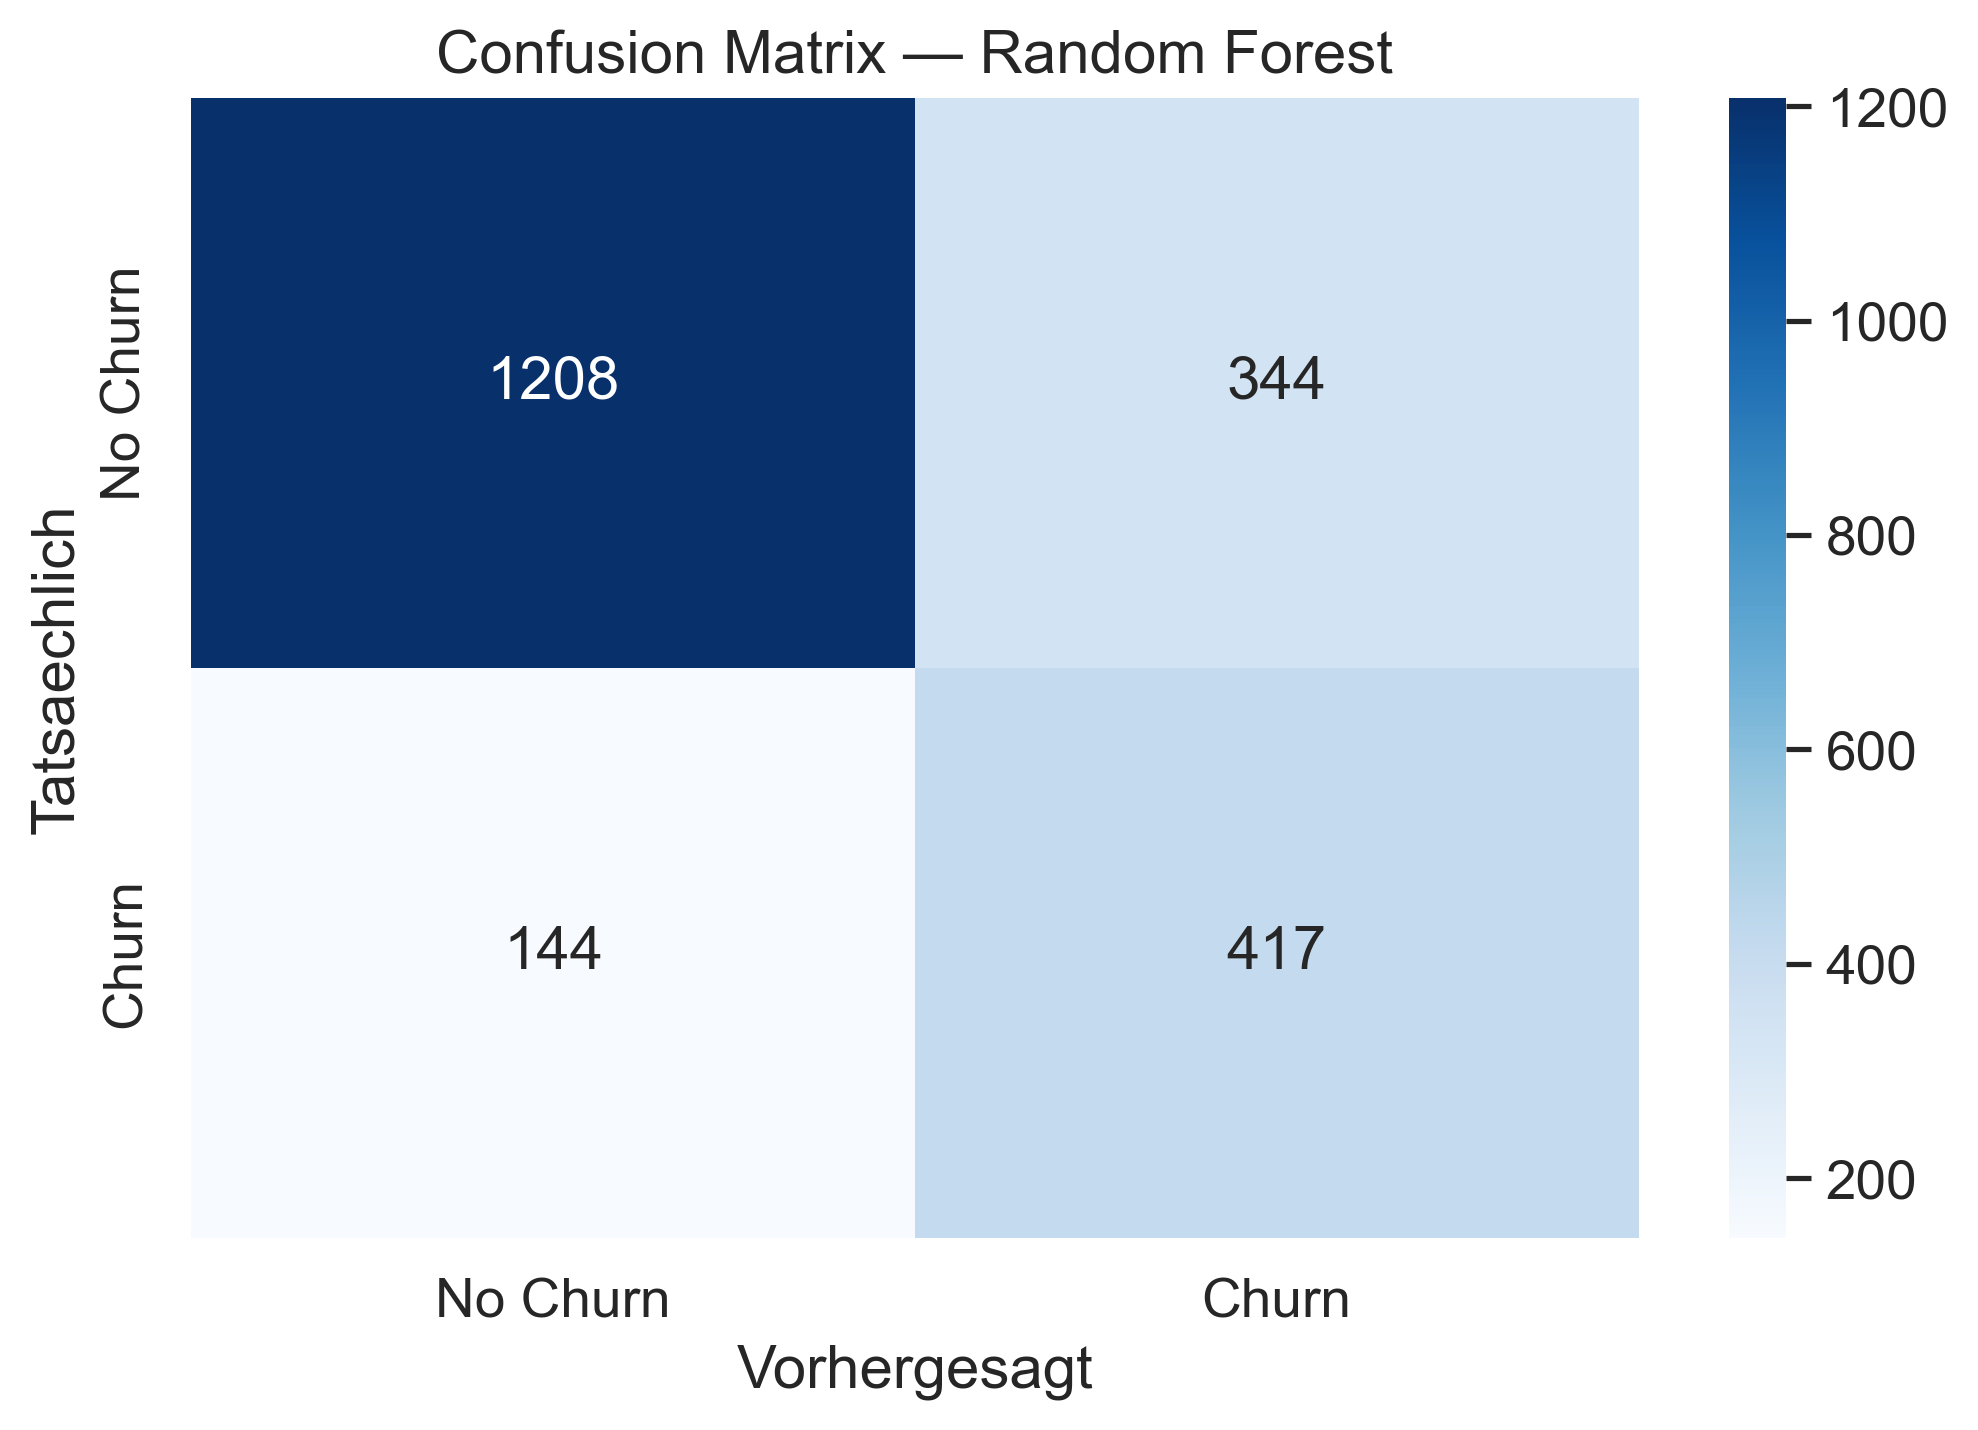

In [8]:
plot_confusion_matrix(y_test, res_rf_tuned["y_pred"], model_name="Random Forest", filename="13_confusion_matrix_random_forest.png")
plt.show()

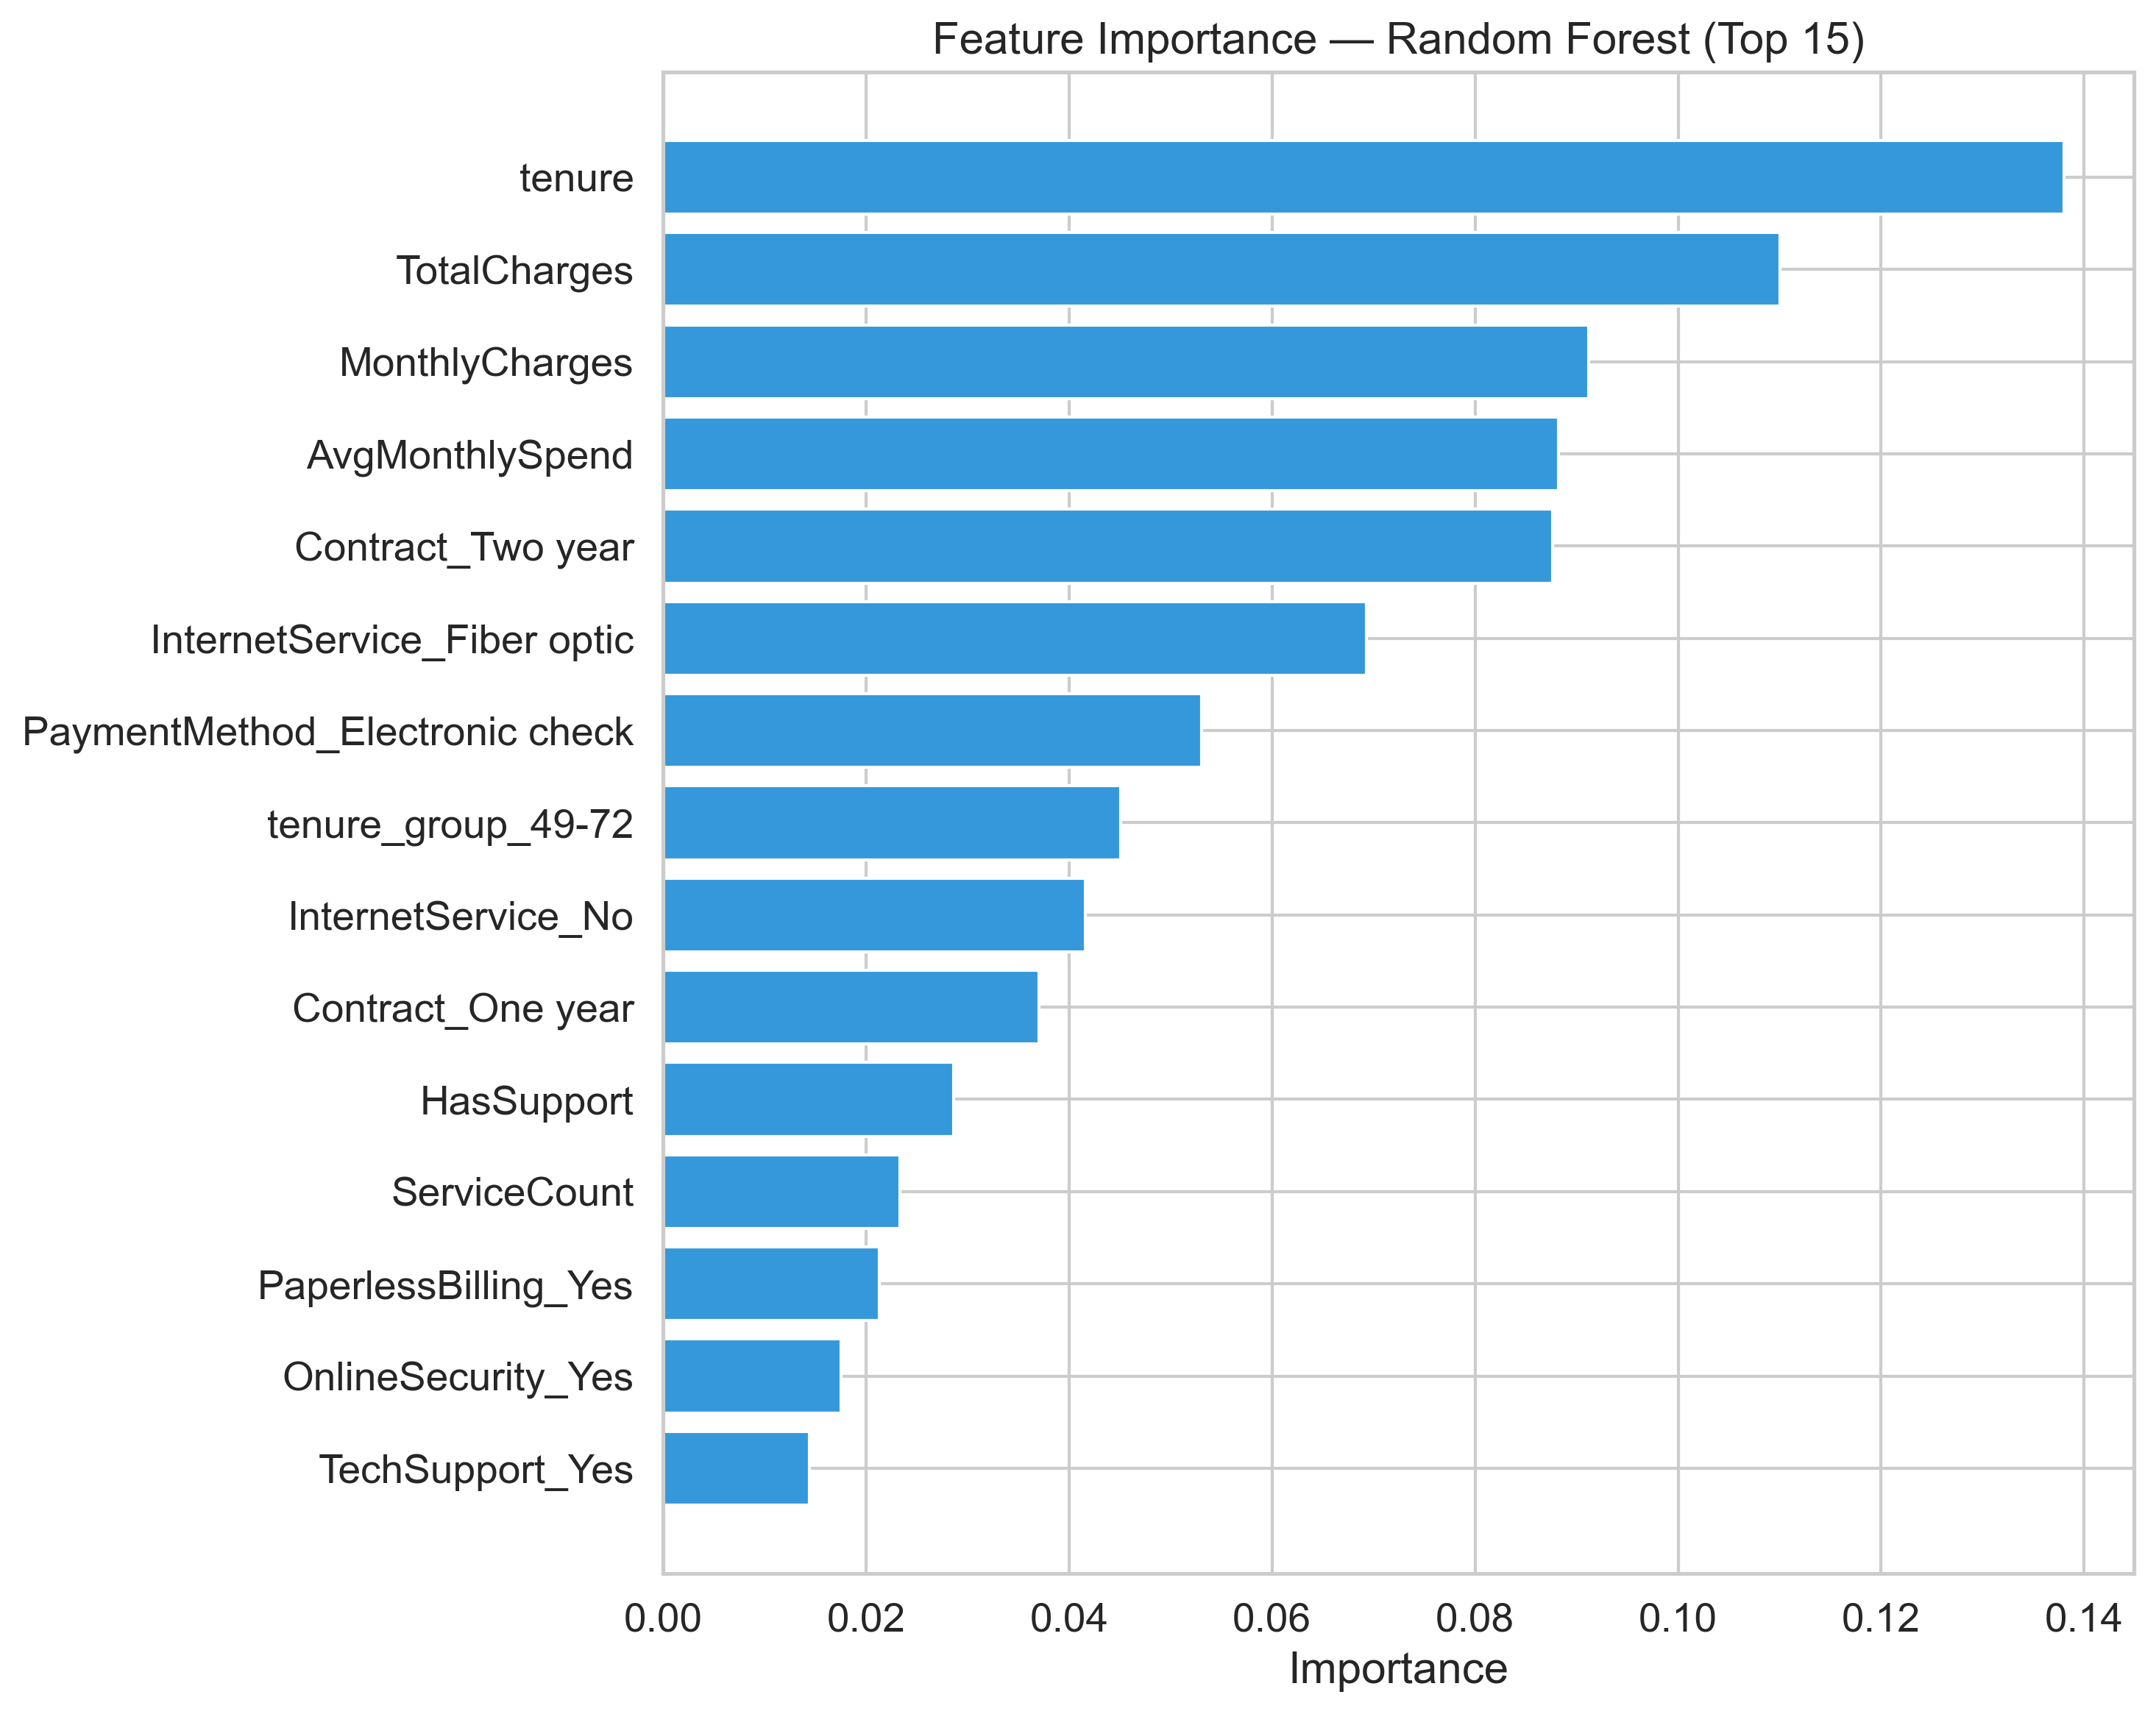

In [9]:
plot_feature_importance(rf_tuned, feature_names, top_n=15, model_name="Random Forest", filename="14_feature_importance_random_forest.png")
plt.show()

---
## 7. XGBoost

### 7.1 Ohne Class Balancing

In [10]:
xgb_plain = train_xgboost(X_train, y_train)
res_xgb_plain = evaluate_model(xgb_plain, X_test, y_test, "XGB (unbalanced)")

C:\Users\simon\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:15:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



  XGB (unbalanced)
              precision    recall  f1-score   support

           0     0.8285    0.8963    0.8610      1552
           1     0.6290    0.4866    0.5487       561

    accuracy                         0.7875      2113
   macro avg     0.7288    0.6914    0.7049      2113
weighted avg     0.7755    0.7875    0.7781      2113

AUC-ROC: 0.8269


### 7.2 Mit Class Balancing

In [11]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_balanced = train_xgboost(X_train, y_train, scale_pos_weight=scale_pos_weight)
res_xgb_balanced = evaluate_model(xgb_balanced, X_test, y_test, "XGB (balanced)")

print("\n--- Vergleich Vorher/Nachher ---")
print(f"Recall: {res_xgb_plain['recall']:.3f} -> {res_xgb_balanced['recall']:.3f}")
print(f"F1:     {res_xgb_plain['f1']:.3f} -> {res_xgb_balanced['f1']:.3f}")

scale_pos_weight: 2.77


C:\Users\simon\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:15:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



  XGB (balanced)
              precision    recall  f1-score   support

           0     0.8875    0.7674    0.8231      1552
           1     0.5318    0.7308    0.6156       561

    accuracy                         0.7577      2113
   macro avg     0.7096    0.7491    0.7193      2113
weighted avg     0.7930    0.7577    0.7680      2113

AUC-ROC: 0.8290

--- Vergleich Vorher/Nachher ---
Recall: 0.487 -> 0.731
F1:     0.549 -> 0.616


### 7.3 Hyperparameter-Tuning

In [12]:
xgb_tuned, xgb_search = tune_xgboost(
    X_train, y_train, n_iter=50, cv=5,
    scale_pos_weight=scale_pos_weight,
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


C:\Users\simon\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:16:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Beste Parameter: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Bester F1 (CV): 0.6329


In [13]:
res_xgb_tuned = evaluate_model(xgb_tuned, X_test, y_test, "XGB (tuned)")
res_xgb_tuned["y_test"] = y_test


  XGB (tuned)
              precision    recall  f1-score   support

           0     0.9079    0.7307    0.8097      1552
           1     0.5162    0.7950    0.6260       561

    accuracy                         0.7478      2113
   macro avg     0.7121    0.7628    0.7178      2113
weighted avg     0.8039    0.7478    0.7609      2113

AUC-ROC: 0.8412


### 7.4 Ergebnis-Outputs

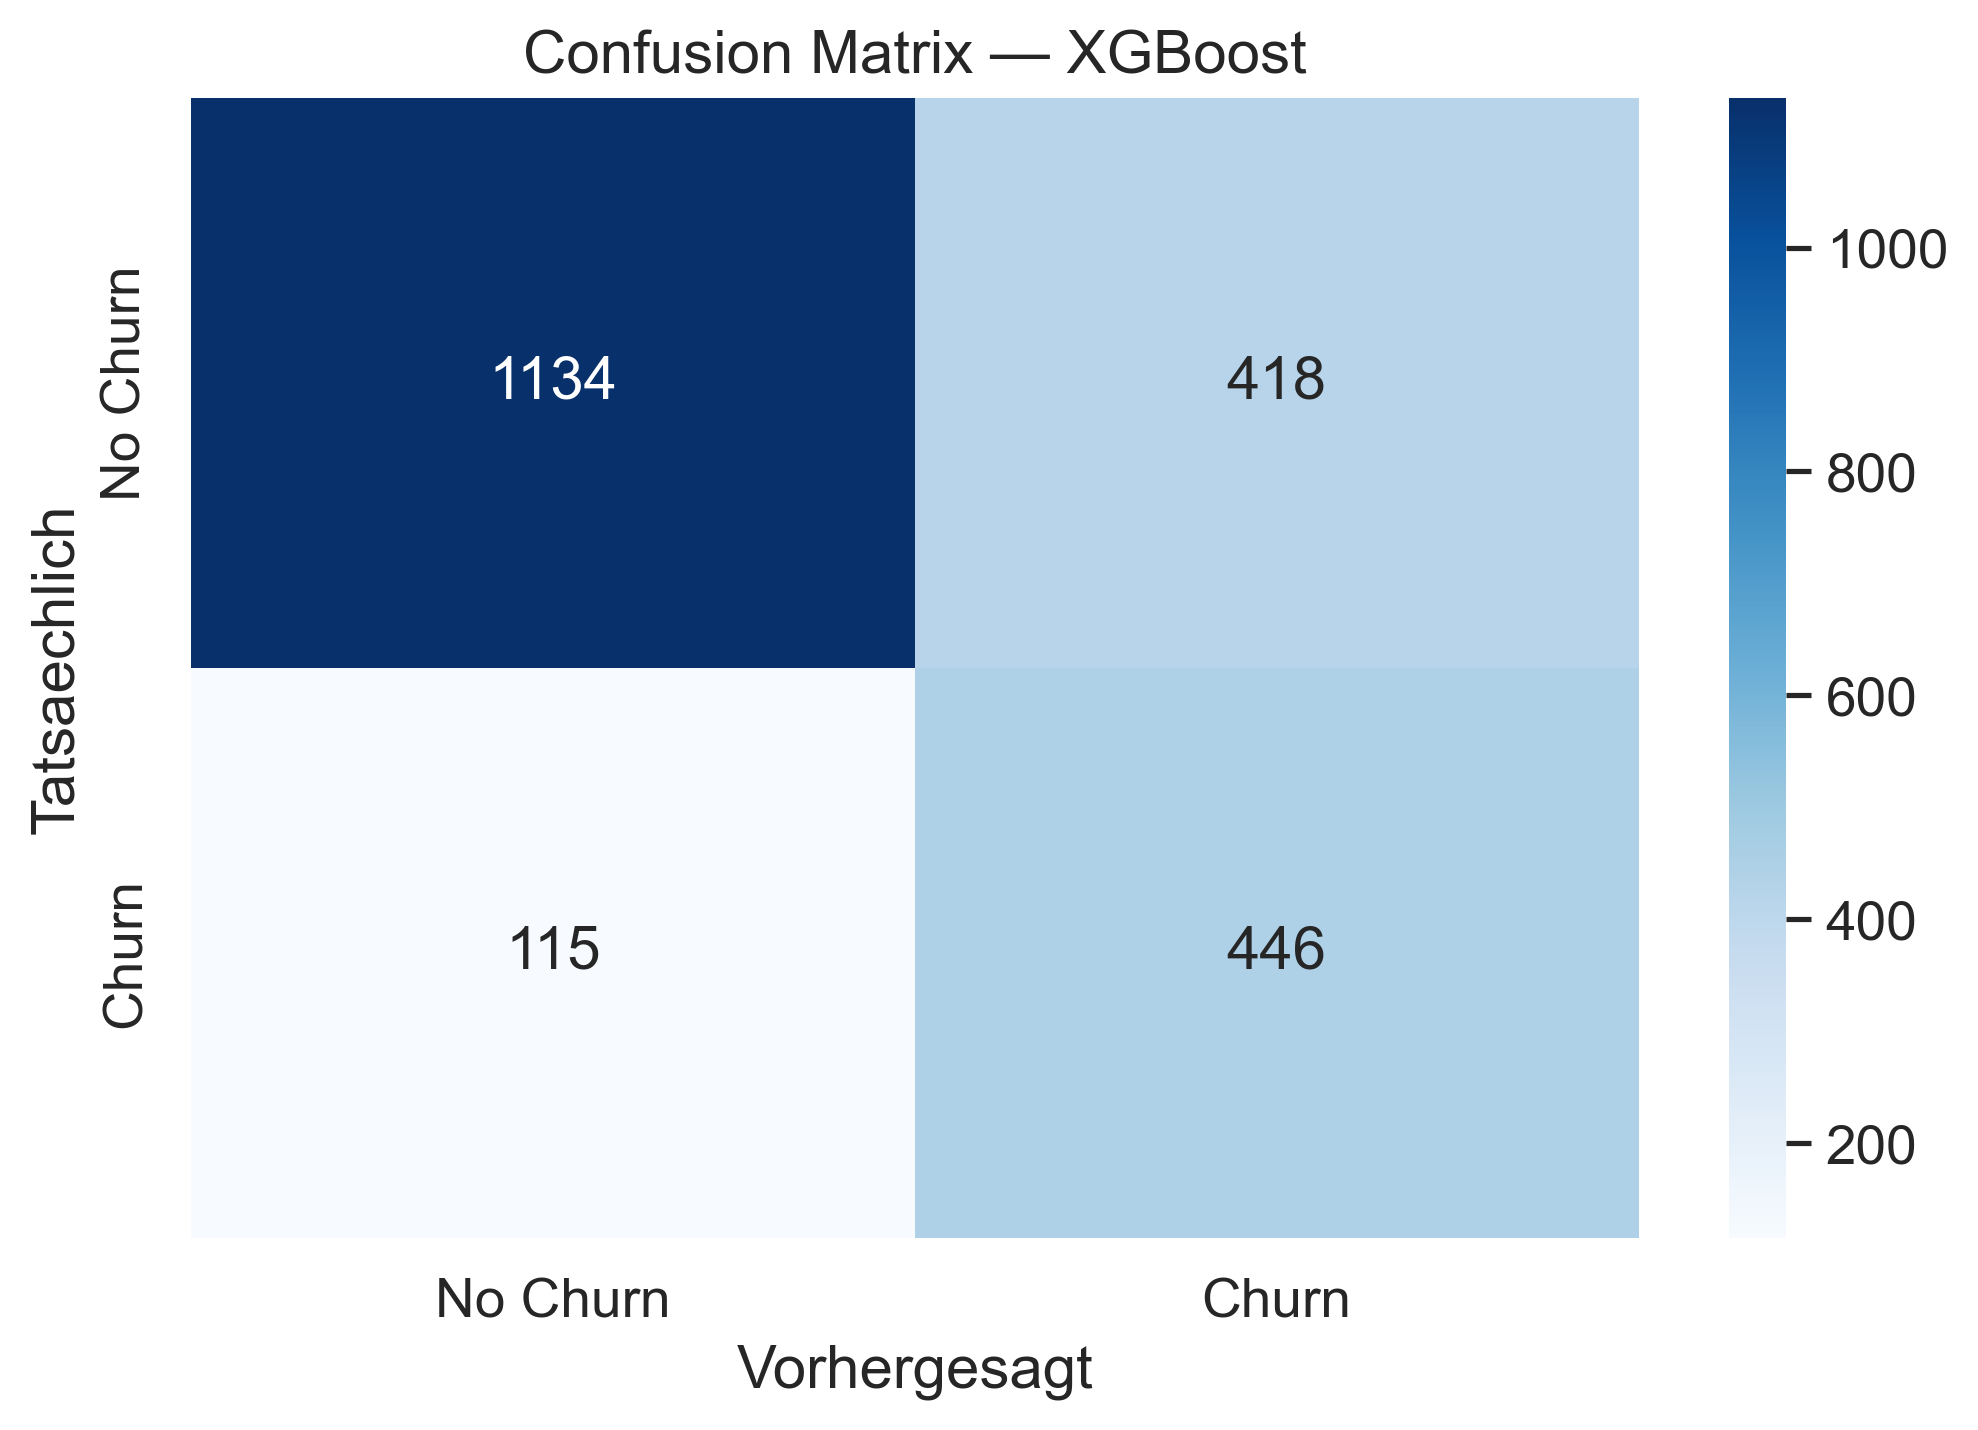

In [14]:
plot_confusion_matrix(y_test, res_xgb_tuned["y_pred"], model_name="XGBoost", filename="15_confusion_matrix_xgboost.png")
plt.show()

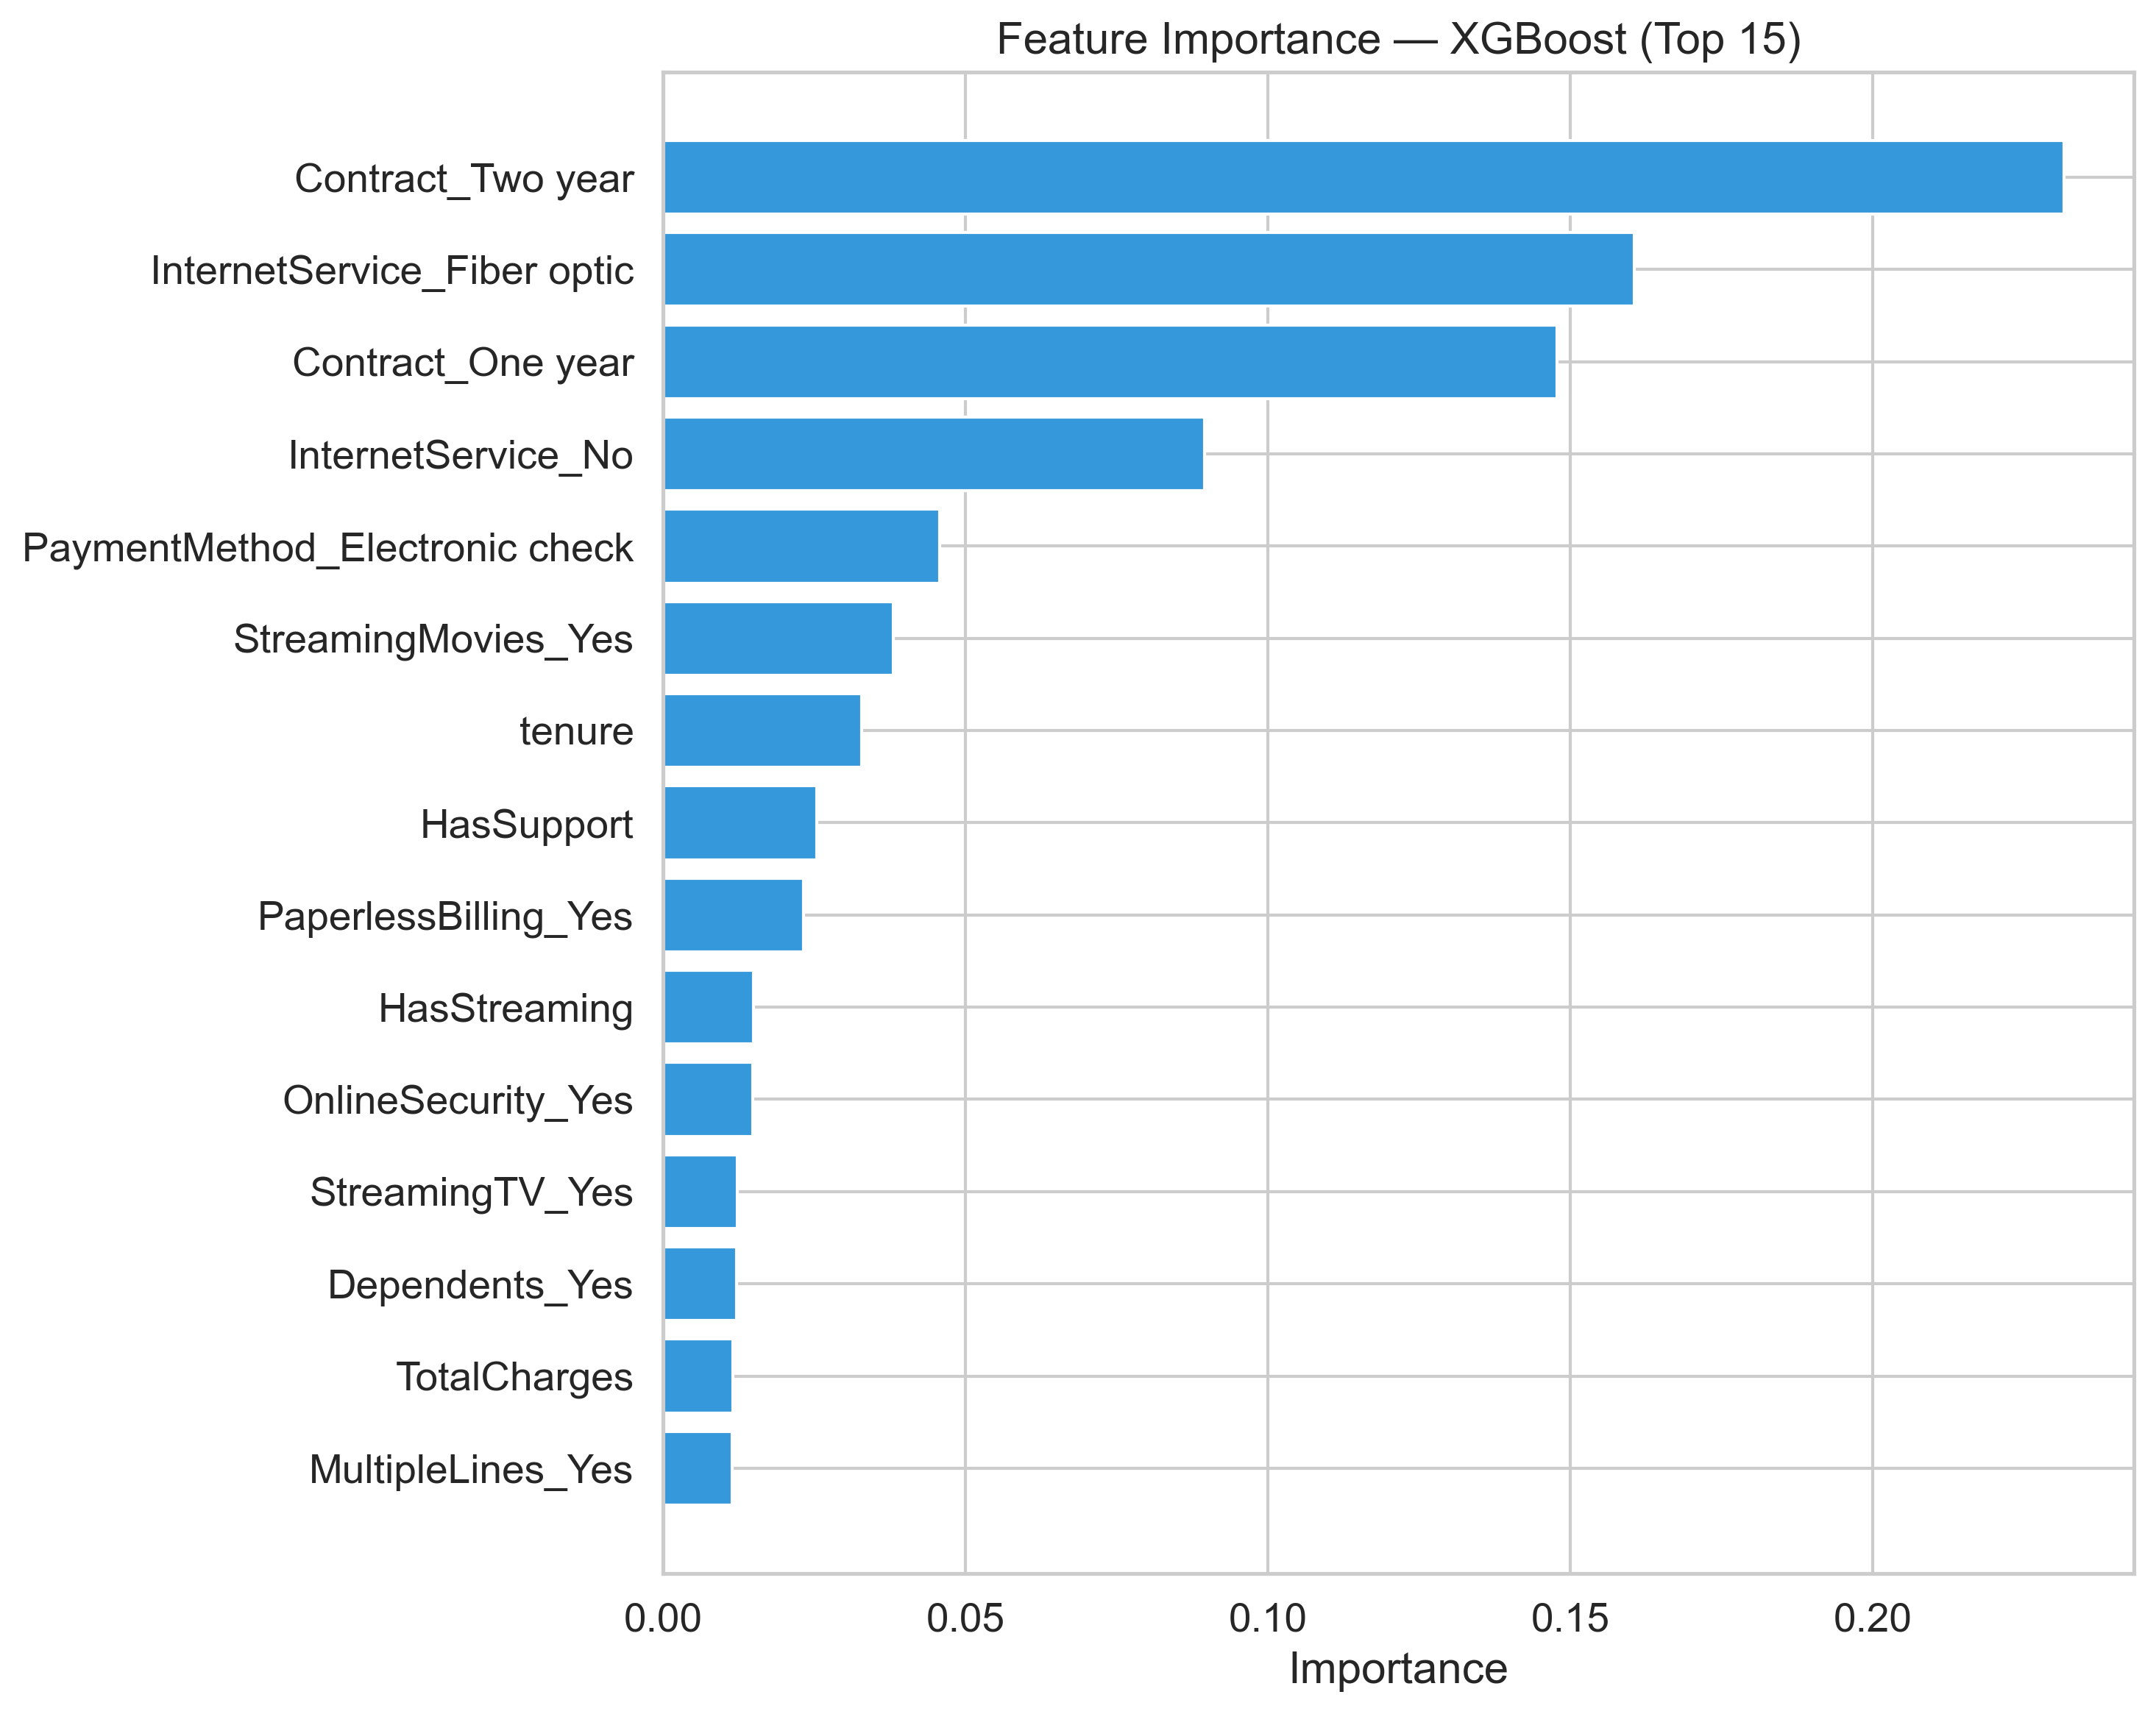

In [15]:
plot_feature_importance(xgb_tuned, feature_names, top_n=15, model_name="XGBoost", filename="16_feature_importance_xgboost.png")
plt.show()

---
## 7b. Logistische Regression (Anhang)

Einfachstes Vergleichsmodell fuer Rueckfragen. Features werden mit `StandardScaler` skaliert (bei Baummodellen nicht noetig, bei LR schon).

In [16]:
model_lr, scaler_lr = train_logistic_regression(X_train, y_train)

X_test_scaled = scaler_lr.transform(X_test)
res_lr = evaluate_model(model_lr, X_test_scaled, y_test, "Log. Regression")
res_lr["y_test"] = y_test


  Log. Regression
              precision    recall  f1-score   support

           0     0.9068    0.7268    0.8069      1552
           1     0.5121    0.7932    0.6224       561

    accuracy                         0.7444      2113
   macro avg     0.7094    0.7600    0.7146      2113
weighted avg     0.8020    0.7444    0.7579      2113

AUC-ROC: 0.8443


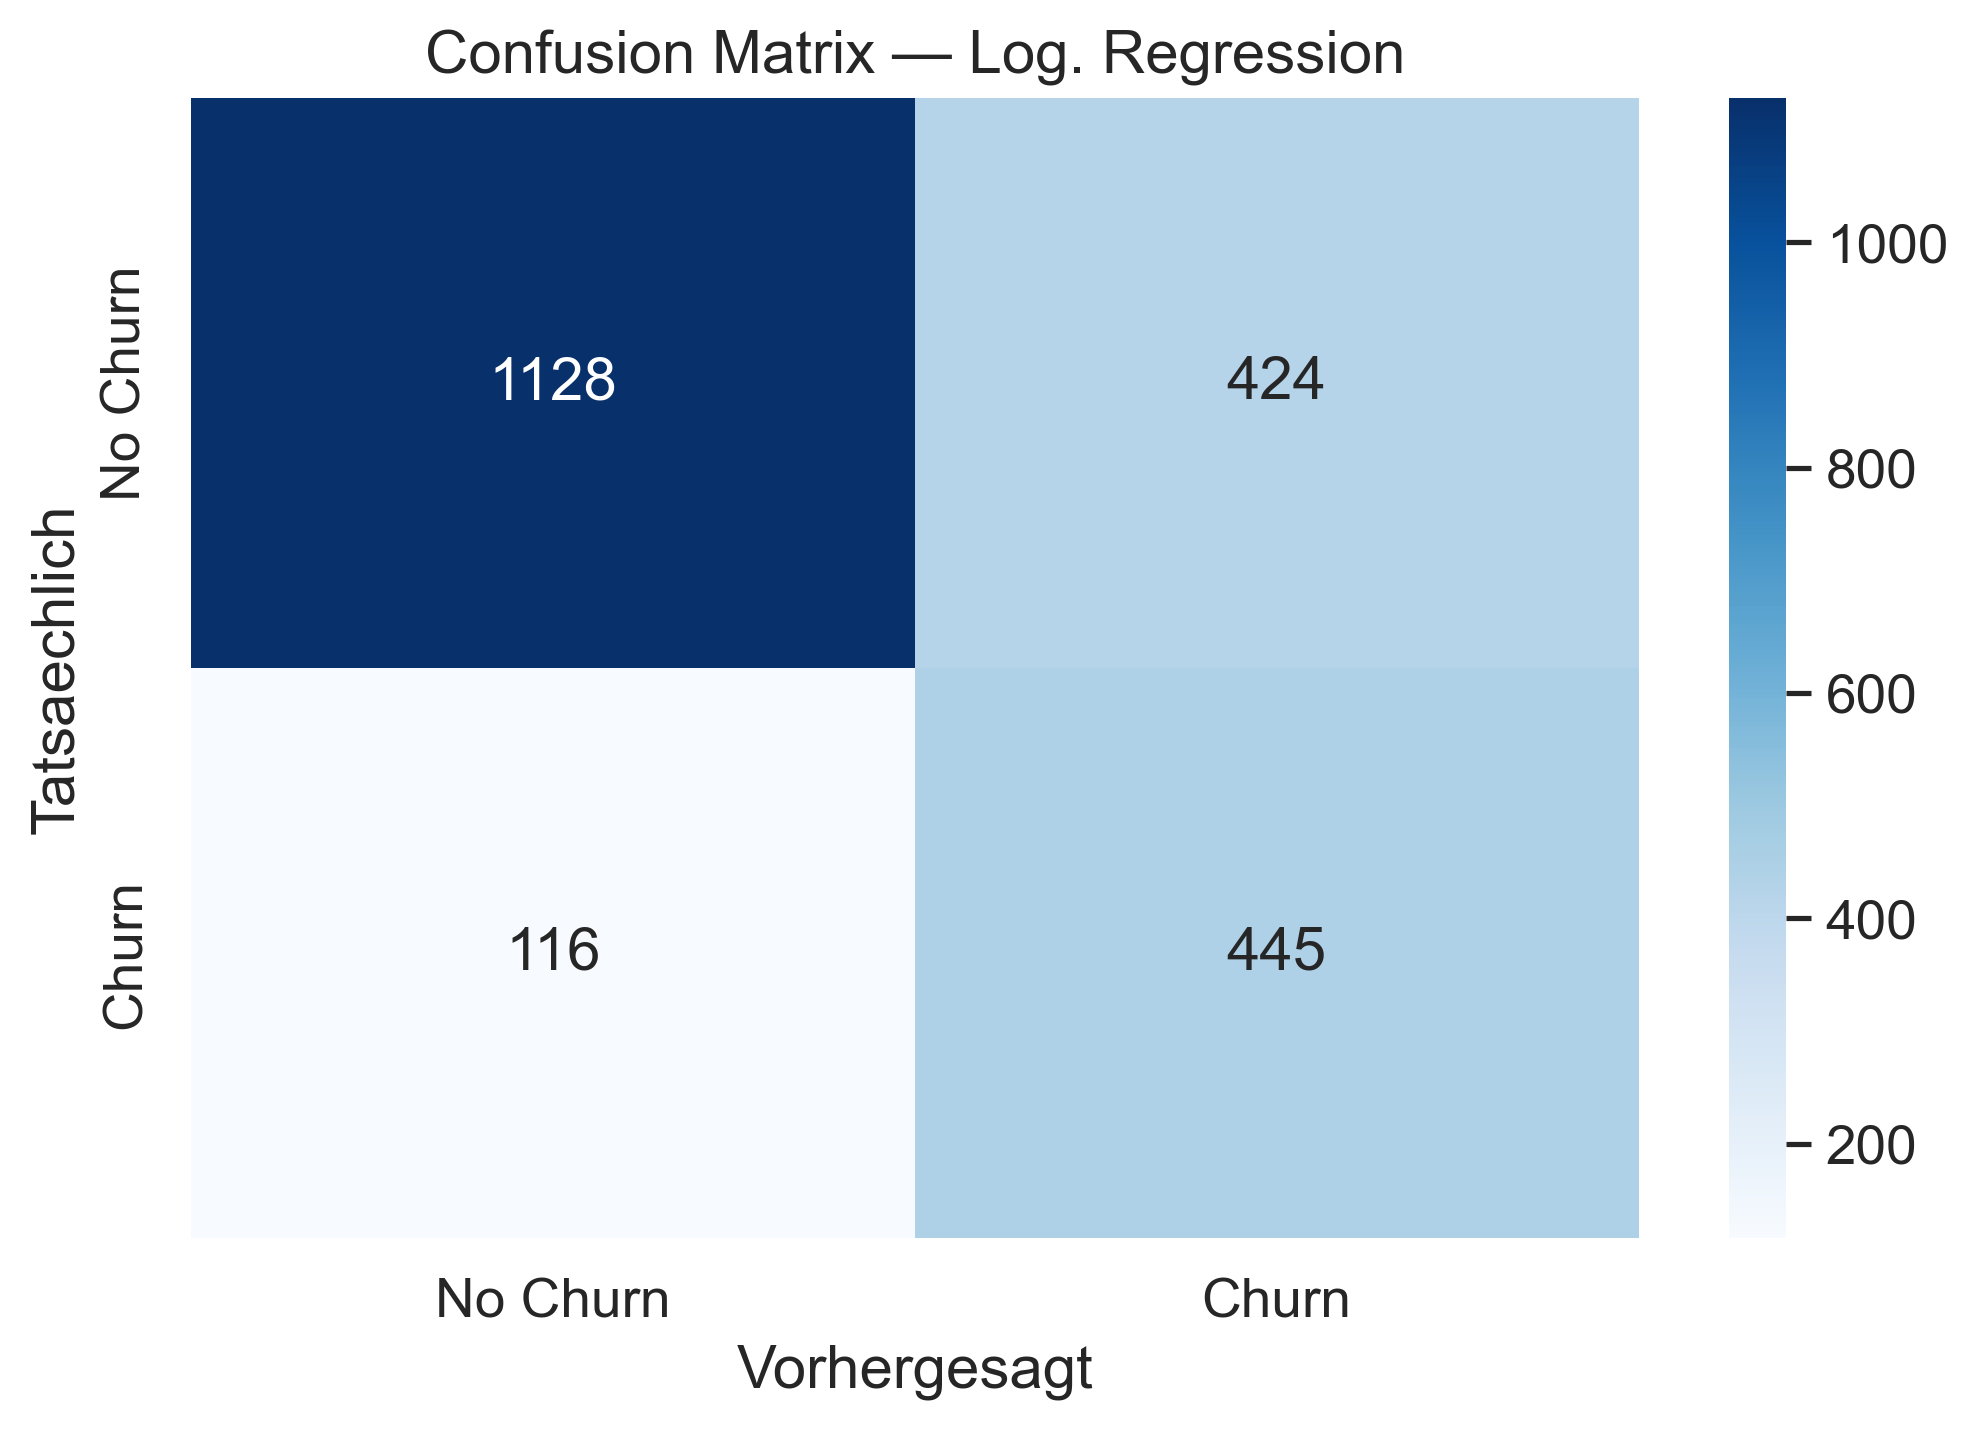

In [17]:
plot_confusion_matrix(y_test, res_lr["y_pred"], model_name="Log. Regression", filename="17_lr_confusion_matrix.png")
plt.show()

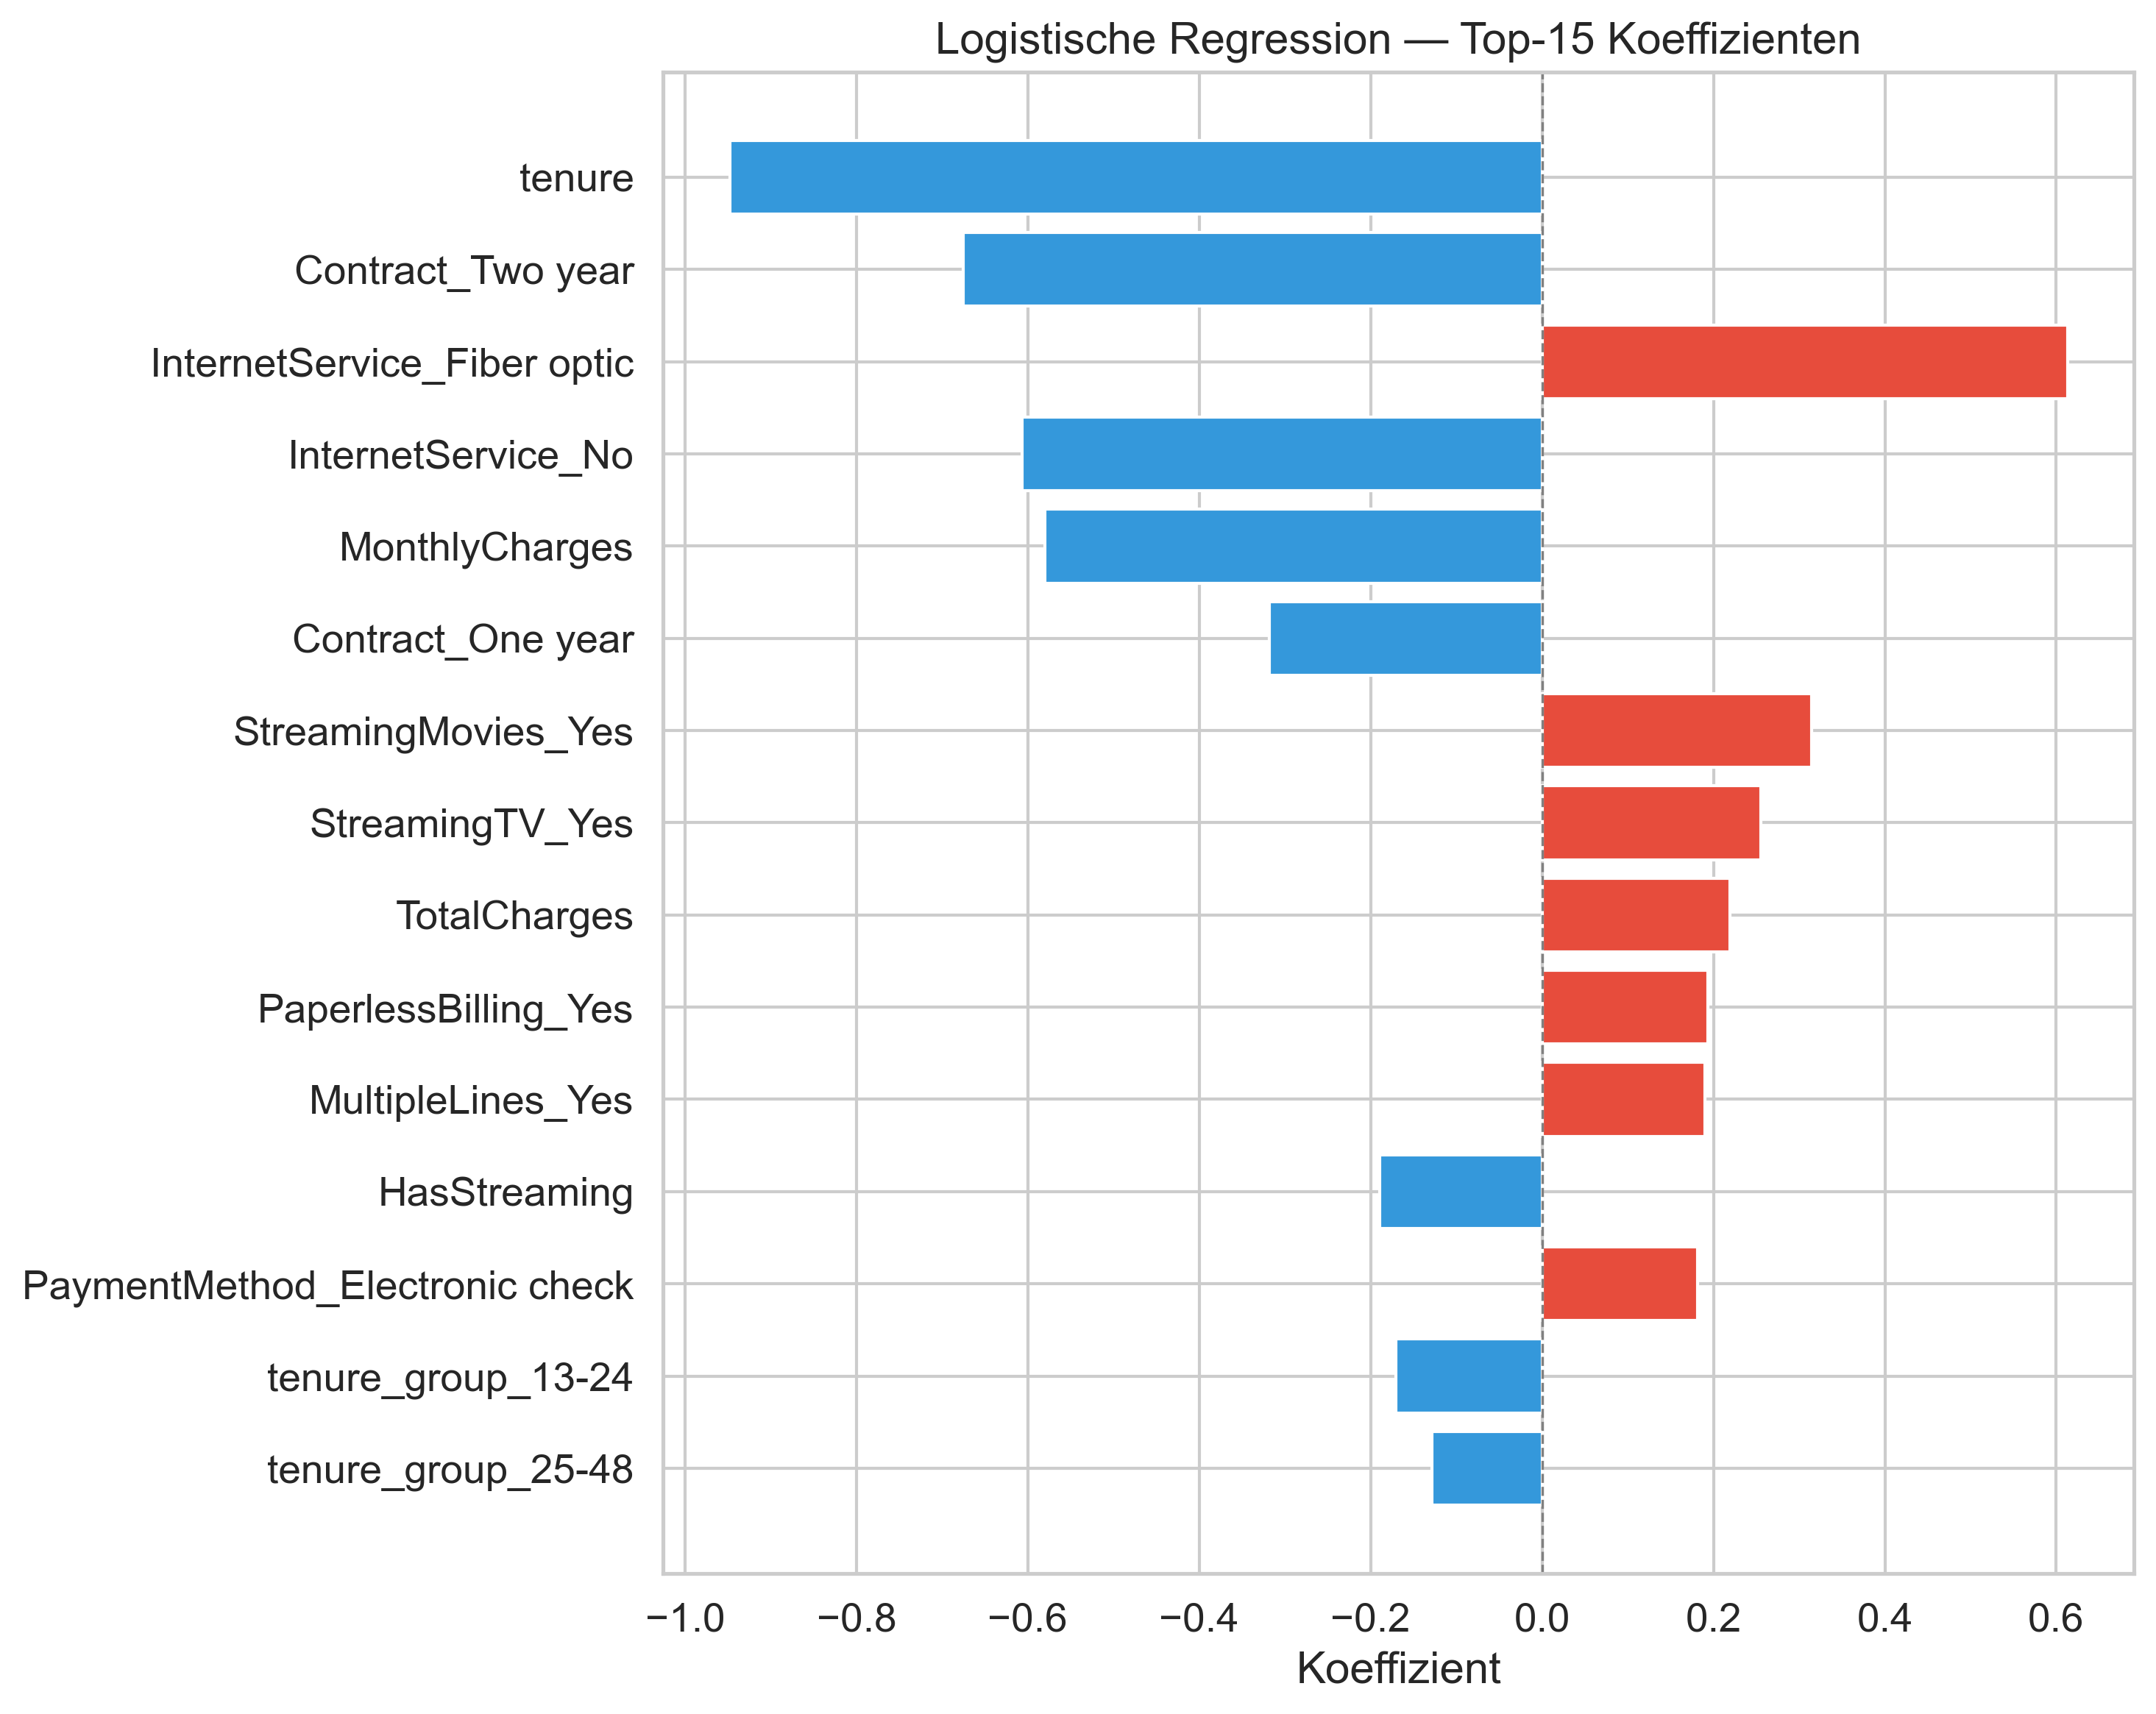

In [18]:
plot_coefficients(model_lr, feature_names, top_n=15, filename="18_lr_coefficients.png")
plt.show()

---
## 8. Champion-Challenger Vergleich

### 8.1 Metriken-Vergleich

In [19]:
all_results = [res_baseline, res_lr, res_rf_tuned, res_xgb_tuned]
comparison_df = compare_models(all_results)
comparison_df.style.format("{:.4f}").highlight_max(axis=0, color="lightgreen")

,Accuracy,Precision,Recall,F1,AUC-ROC
Modell,,,,,
Baseline-Regel,0.7444,0.5187,0.5205,0.5196,0.6729
Log. Regression,0.7444,0.5121,0.7932,0.6224,0.8443
RF (tuned),0.7690,0.5480,0.7433,0.6309,0.8444
XGB (tuned),0.7478,0.5162,0.7950,0.6260,0.8412


### 8.2 ROC-Kurven ueberlagert

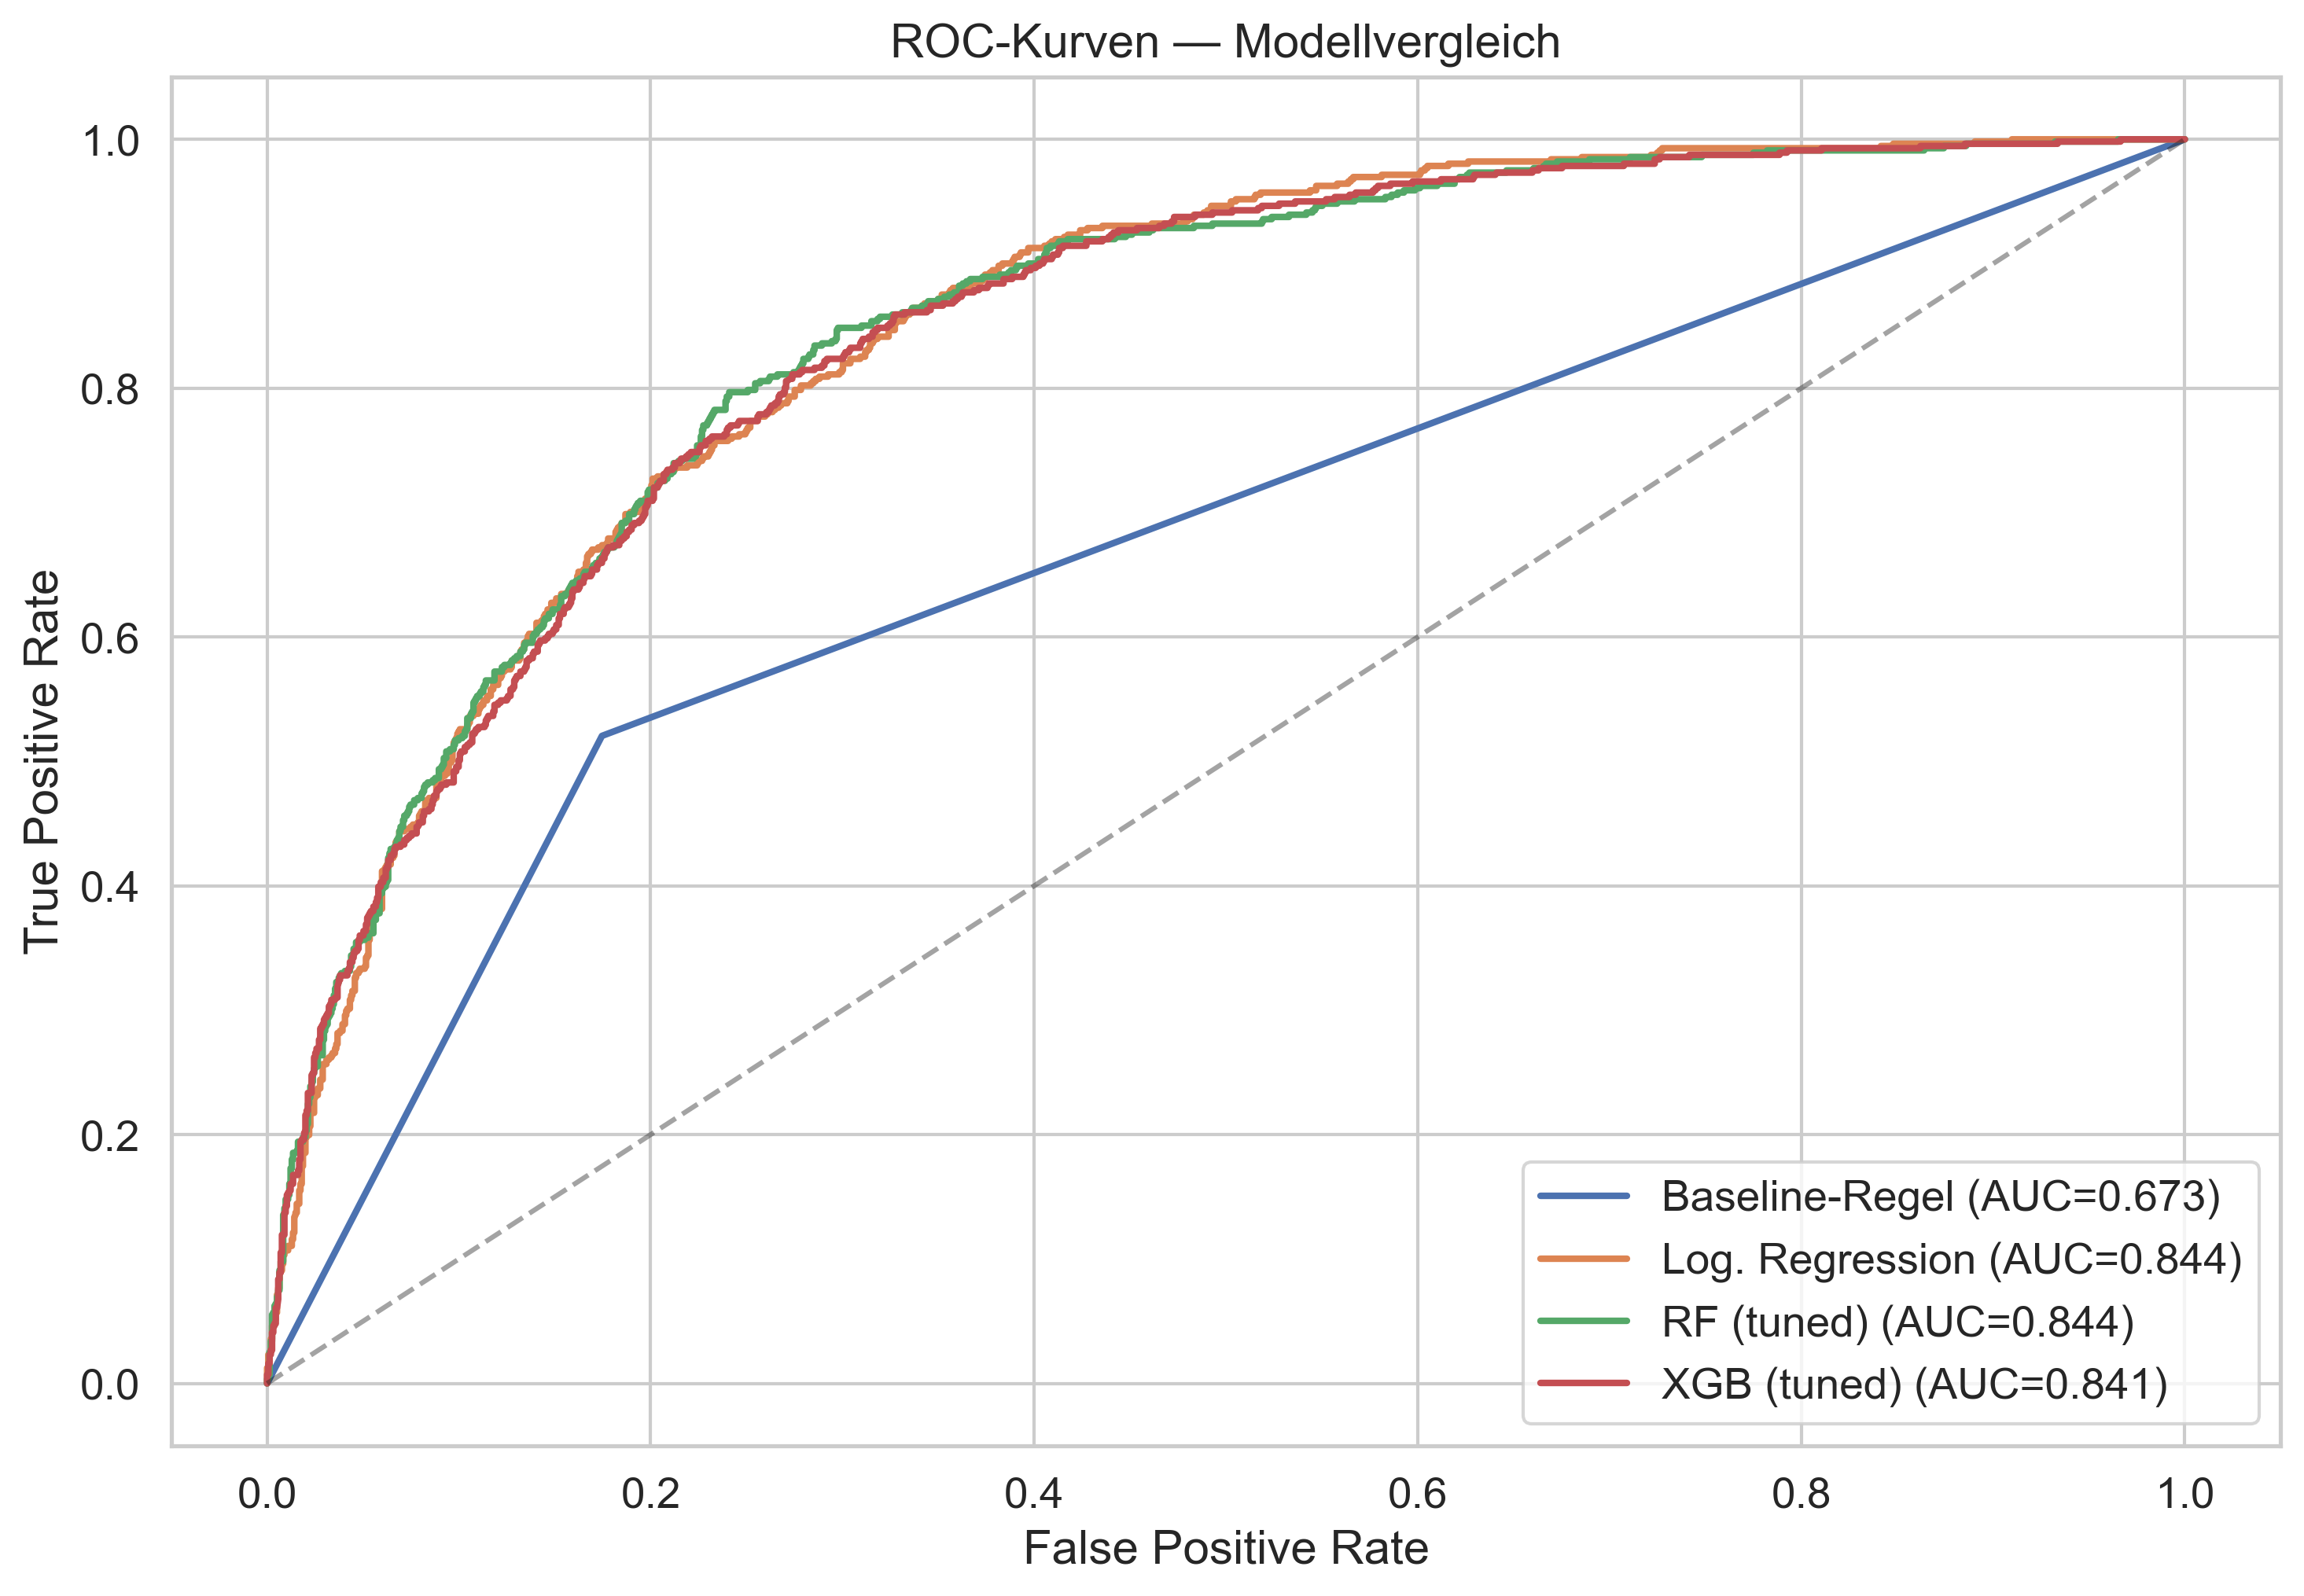

In [20]:
plot_roc_curves(all_results, filename="19_roc_comparison_all.png")
plt.show()

### 8.3 Schwellenwert-Analyse

In [21]:
thresh_df = threshold_analysis(
    y_test, res_xgb_tuned["y_prob"],
    thresholds=[0.3, 0.35, 0.4, 0.45, 0.5],
)
thresh_df.style.format({
    "Schwellenwert": "{:.2f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1": "{:.3f}",
    "Kosten FN (CHF)": "{:,.0f}",
    "Kosten FP (CHF)": "{:,.0f}",
    "Gesamtkosten (CHF)": "{:,.0f}",
})

,Schwellenwert,Precision,Recall,F1,Alarme (TP+FP),Uebersehene Churner (FN),Kosten FN (CHF),Kosten FP (CHF),Gesamtkosten (CHF)
0,0.30,0.446,0.900,0.597,1132,56,"112,000","31,350","143,350"
1,0.35,0.459,0.881,0.603,1077,67,"134,000","29,150","163,150"
2,0.40,0.478,0.861,0.615,1010,78,"156,000","26,350","182,350"
3,0.45,0.497,0.831,0.622,938,95,"190,000","23,600","213,600"
4,0.50,0.516,0.795,0.626,864,115,"230,000","20,900","250,900"


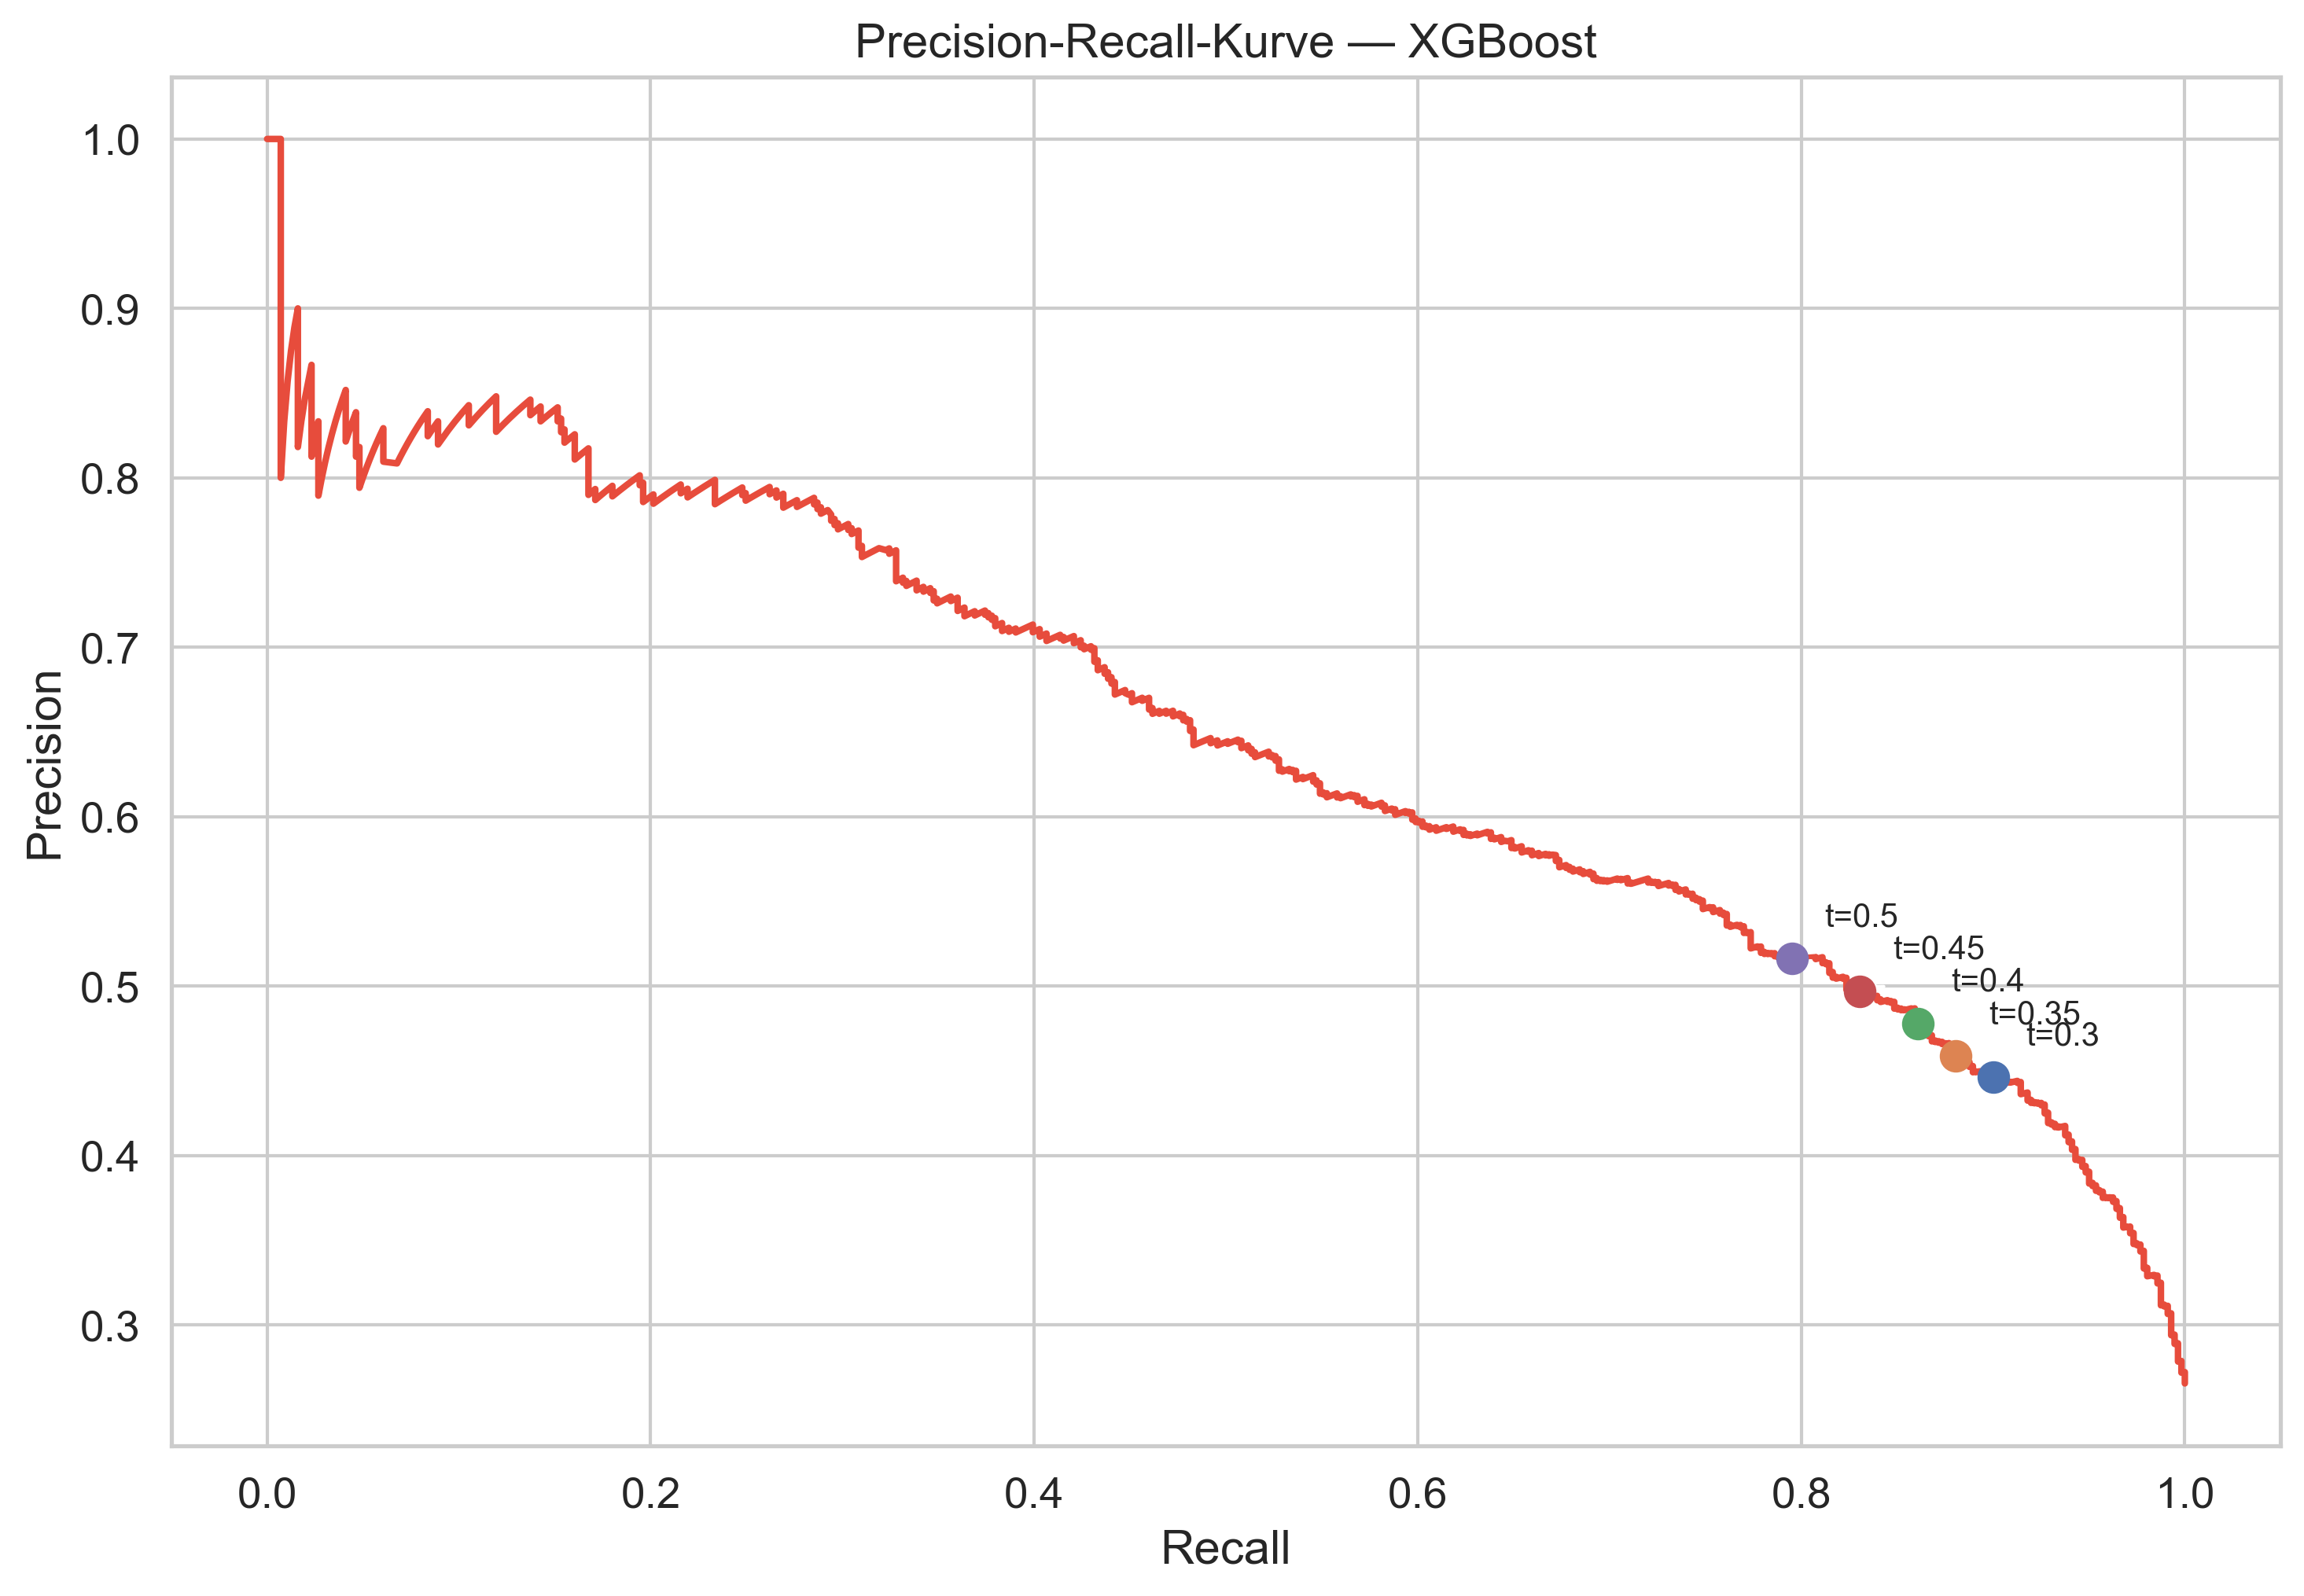

In [22]:
plot_precision_recall_curve(y_test, res_xgb_tuned["y_prob"], model_name="XGBoost", filename="20_precision_recall_curve.png")
plt.show()

---
## 10. Class Imbalance: Vorher/Nachher

In [23]:
# SMOTE-Variante (optional)
X_train_smote, y_train_smote = apply_smote(X_train, y_train)
print(f"Vor SMOTE:  {y_train.value_counts().to_dict()}")
print(f"Nach SMOTE: {y_train_smote.value_counts().to_dict()}")

xgb_smote = train_xgboost(X_train_smote, y_train_smote)
res_xgb_smote = evaluate_model(xgb_smote, X_test, y_test, "XGB (SMOTE)")

Vor SMOTE:  {0: 3622, 1: 1308}
Nach SMOTE: {0: 3622, 1: 3622}


C:\Users\simon\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:17:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



  XGB (SMOTE)
              precision    recall  f1-score   support

           0     0.8534    0.8286    0.8408      1552
           1     0.5611    0.6061    0.5827       561

    accuracy                         0.7695      2113
   macro avg     0.7072    0.7173    0.7117      2113
weighted avg     0.7757    0.7695    0.7723      2113

AUC-ROC: 0.8235


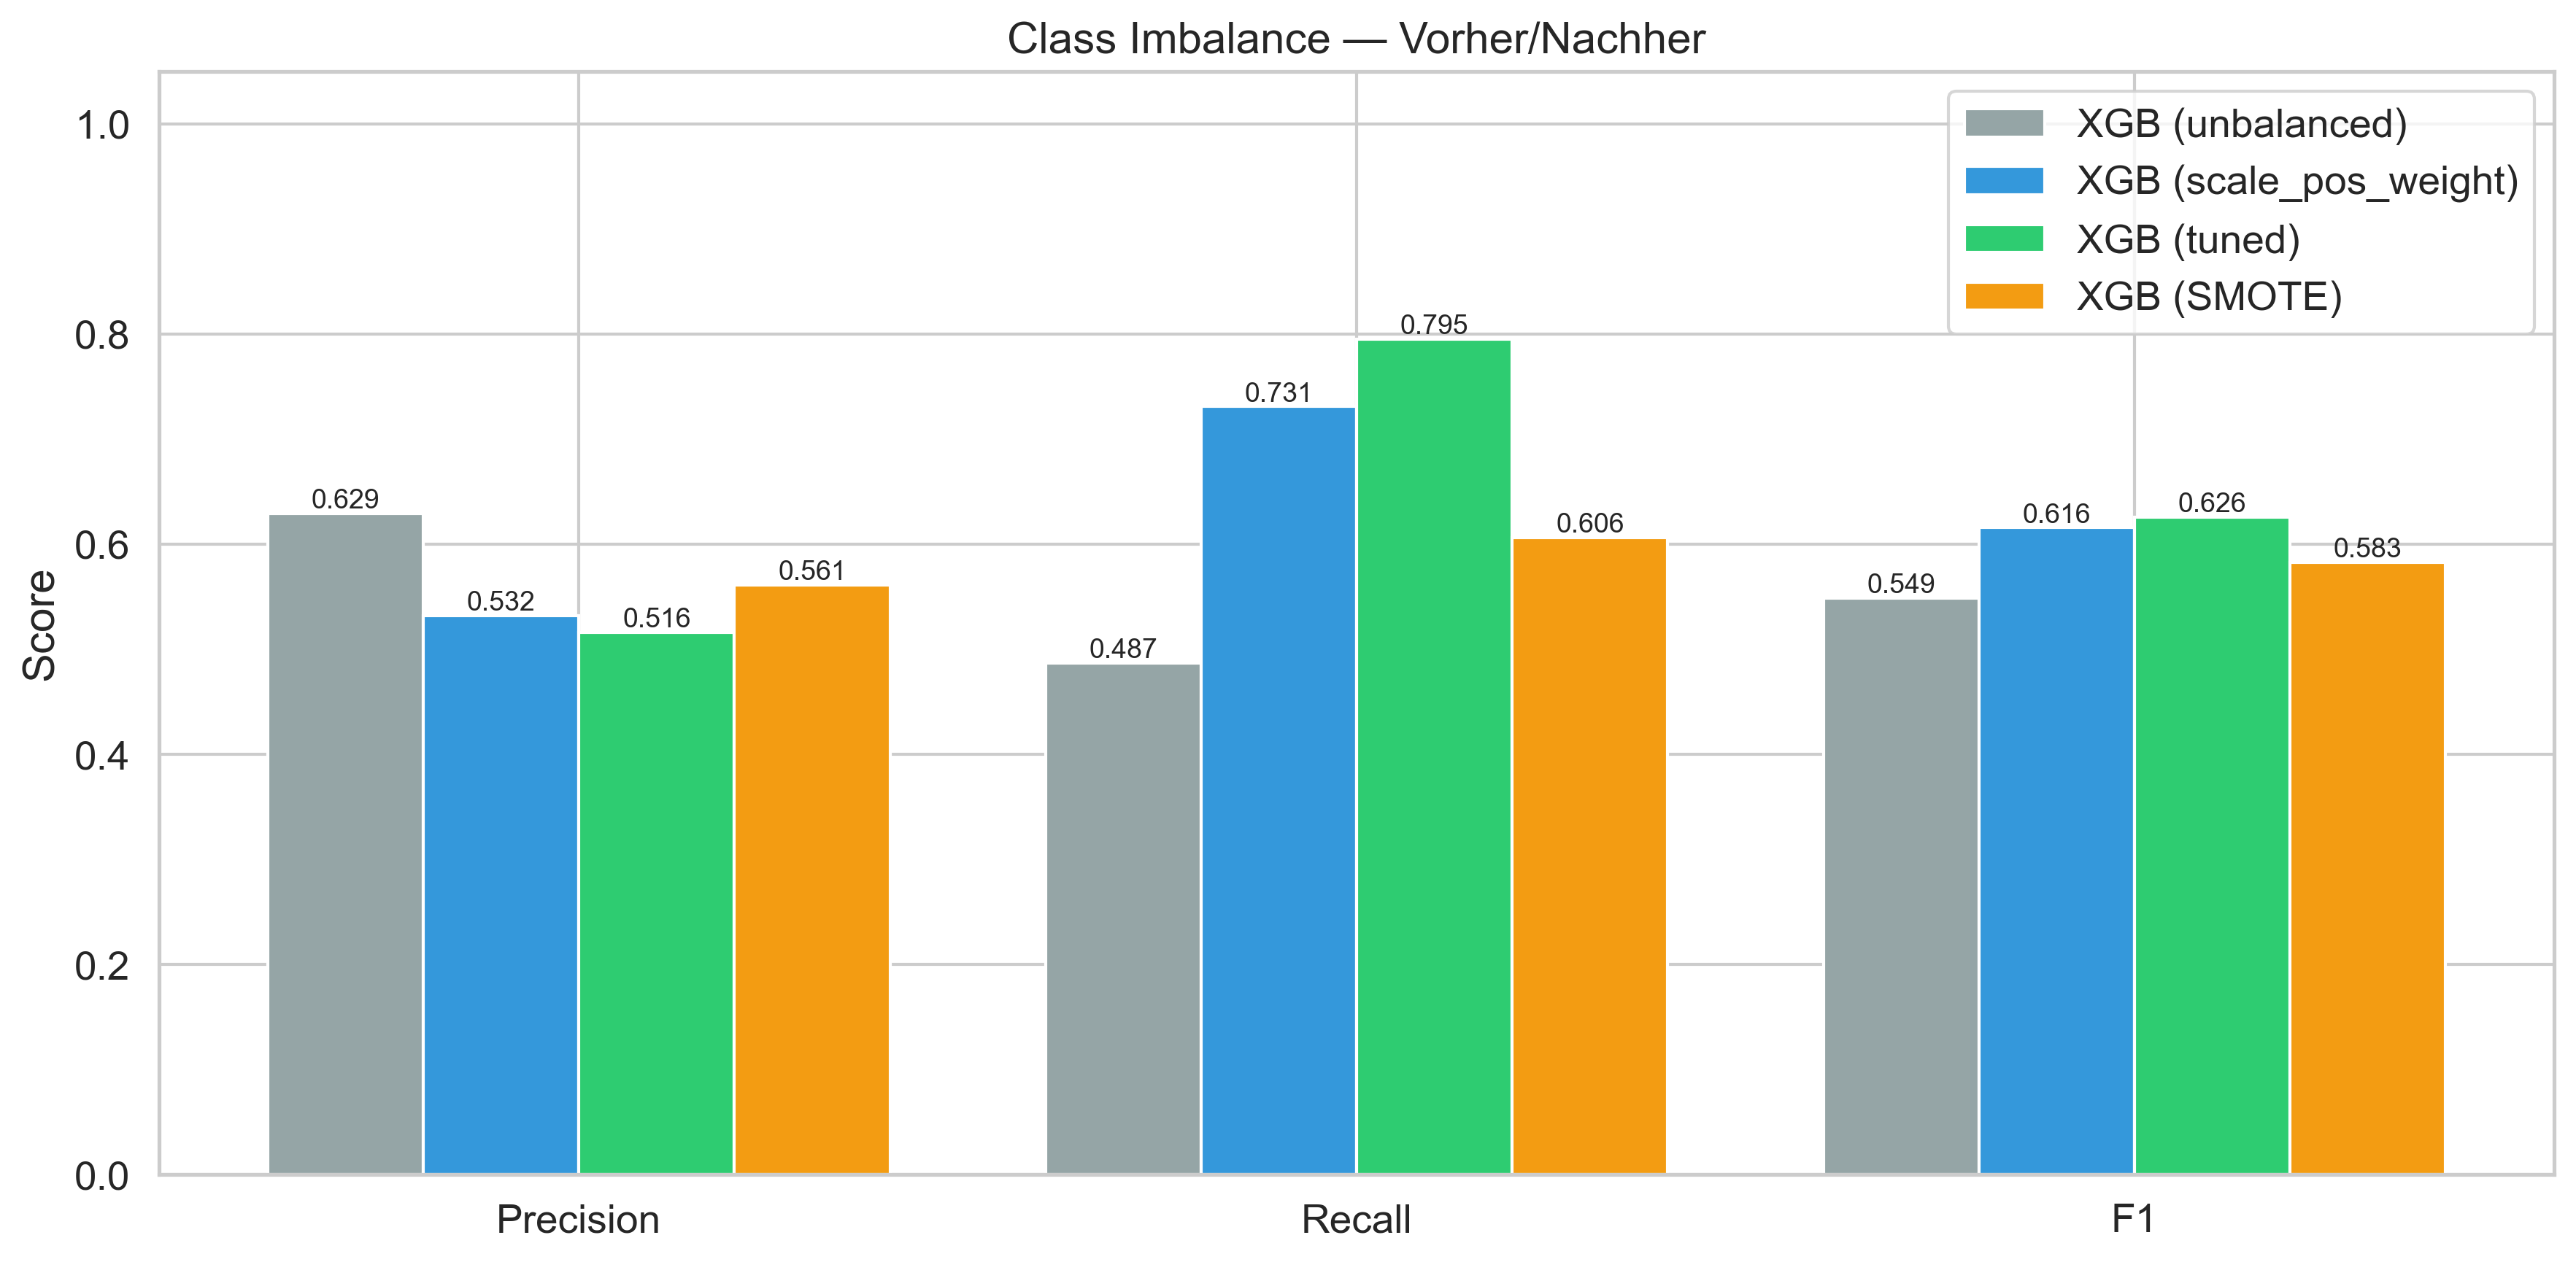

In [24]:
# Vorher/Nachher Vergleich: Barplot
imbalance_results = {
    "XGB (unbalanced)": res_xgb_plain,
    "XGB (scale_pos_weight)": res_xgb_balanced,
    "XGB (tuned)": res_xgb_tuned,
    "XGB (SMOTE)": res_xgb_smote,
}

metrics_to_compare = ["precision", "recall", "f1"]
x = np.arange(len(metrics_to_compare))
width = 0.2
colors = ["#95a5a6", "#3498db", "#2ecc71", "#f39c12"]

fig, ax = plt.subplots(figsize=(12, 6))
for i, (name, res) in enumerate(imbalance_results.items()):
    values = [res[m] for m in metrics_to_compare]
    bars = ax.bar(x + i * width, values, width, label=name, color=colors[i])
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", fontsize=9,
        )

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([m.capitalize() for m in metrics_to_compare])
ax.set_ylabel("Score")
ax.set_title("Class Imbalance — Vorher/Nachher")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
fig.savefig("plots/21_class_imbalance_vergleich.png")
plt.show()

---
## Modelle speichern

In [25]:
joblib.dump(rf_tuned, "models/random_forest.pkl")
joblib.dump(xgb_tuned, "models/xgboost.pkl")
joblib.dump(model_lr, "models/logistic_regression.pkl")
joblib.dump(scaler_lr, "models/scaler_lr.pkl")

# Preprocessing-Info speichern (Feature-Spalten fuer Dashboard)
preprocessor = {
    "feature_columns": list(X_train.columns),
    "median_monthly": X_train["MonthlyCharges"].median() if "MonthlyCharges" in X_train.columns else 70.0,
}
joblib.dump(preprocessor, "models/preprocessor.pkl")

# Metriken-Tabelle speichern
comparison_df.to_csv("data/processed/metriken_vergleich.csv")
thresh_df.to_csv("data/processed/schwellenwert_analyse.csv", index=False)

print("Modelle und Metriken gespeichert.")

Modelle und Metriken gespeichert.
